# DocMind — Retrieval Research Benchmark (Clean Corpus)

This notebook is the new research track for **text-document retrieval only**.

## Goal
Measure which combination of:
- extraction baseline,
- chunk size,
- embedding model,
- BM25 / dense / hybrid retrieval,
- reranking,

retrieves the **correct evidence passage** most reliably.

## Deliberately excluded
- LLM answer generation
- LLM-as-a-judge
- SQL routing
- giant CSV datasets
- table-heavy grade spreadsheets
- OCR benchmarking

Those become separate notebooks later.

## Experimental rule
**Do not choose a winner using the same questions used for final reporting.**
We will use a development split for configuration selection and a held-out test split for the final result.

In [64]:
# Cell 1 — Install dependencies
!pip install -q \
    pymupdf \
    python-docx \
    python-pptx \
    sentence-transformers \
    transformers \
    faiss-cpu \
    rank-bm25 \
    scikit-learn \
    langchain-text-splitters \
    psutil \
    tqdm

In [65]:
# Cell 2 — Imports and experiment configuration
import os
import re
import gc
import json
import time
import math
import random
import hashlib
import platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import fitz
from docx import Document
from pptx import Presentation

from tqdm.auto import tqdm
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_text_splitters import RecursiveCharacterTextSplitter

from rank_bm25 import BM25Okapi
import faiss

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("/kaggle/input/datasets/ripperdzz/docmind-test")
WORK_DIR = Path("/kaggle/working/docmind_research")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("WORK_DIR :", WORK_DIR)
print("CPU cores:", os.cpu_count())
print("RAM GB   :", round(psutil.virtual_memory().total / 1024**3, 2))

DATA_DIR : /kaggle/input/datasets/ripperdzz/docmind-test
WORK_DIR : /kaggle/working/docmind_research
CPU cores: 4
RAM GB   : 31.35


In [66]:
EXPECTED_FILES = ['1. Introduction.pdf', '10. HMM.pdf', '11. DTW.pdf', '2. Concepts fondamentaux.pdf', '3. Regression.pdf', '4. Regression Logistique.pdf', '5. Non-paramtriques-KNN.pdf', '6. Naive Bayes.pdf', '7. Clustering - part2.pdf', '7. Clustering-part1.pdf', '8. ANN-part1.pdf', '8. ANN-part2.pdf', '9. SVM.pdf', 'AI and Biases.pptx', 'Academic writing.pptx', 'An introduction to Cognitive Science.pptx', 'Artificial Intelligence - An Overview.pptx', 'BMC I2E final1 (1).docx', 'Cc_Logique_Mathematique_2015-2016.docx', 'Ch1_Algbre1-2021-2022.pdf', 'Ch2_Algbre1-2021-2022.pdf', 'Chap5_cours_Analyse1.pdf', 'Cloud Computing Enhancing AI.pptx', 'Cours_Data_ScienceComplet.pdf', 'Data Science Examen de Remplacement.pdf', 'Ethical AI.pptx', 'Examen Final (Corrig).pdf', 'Intelligence Theory and Brain Properties.pptx', 'L1_MI_TD0_analyse2_21.pdf', 'L1_MI_TD1_analyse2_21.pdf', 'L1_MI_TD2_Analyse2_21.pdf', 'Machine Learning.pptx', 'RNN.pptx', 'Rattrapage Data Science IA.pdf', 'Software Processes and Agile Practices.pdf', 'Solution Data Science Examen (1) (1).pdf', 'Sujet_corrige_CC_Analyse-1_21-22.pdf', 'TD N2-DM-25-26.pdf', 'TP-N2-2023-2024.docx', 'Transformers.pptx', 'controle-systeme-1-2019.docx', 'controle-systeme-2020.docx', 'controle-tp-finale-2016.docx', 'frequents-sequence-2026-P1.pdf']

print("Expected corpus files:", len(EXPECTED_FILES))


Expected corpus files: 44


In [67]:
# Cell 4 — Discover files and enforce the clean corpus allow-list

all_found = []
for root, _, filenames in os.walk(DATA_DIR):
    for name in filenames:
        all_found.append(Path(root) / name)

found_by_name = {p.name: p for p in all_found}

missing = [name for name in EXPECTED_FILES if name not in found_by_name]
extra = [name for name in found_by_name if name not in set(EXPECTED_FILES)]

print(f"Found in Kaggle dataset : {len(all_found)}")
print(f"Expected clean corpus   : {len(EXPECTED_FILES)}")
print(f"Missing expected files  : {len(missing)}")
print(f"Extra ignored files     : {len(extra)}")

if missing:
    print("\nMISSING:")
    for name in missing:
        print(" -", name)

if extra:
    print("\nIGNORED EXTRAS:")
    for name in extra[:30]:
        print(" -", name)

FILES = [found_by_name[name] for name in EXPECTED_FILES if name in found_by_name]

print("\nFiles that will actually be benchmarked:", len(FILES))

Found in Kaggle dataset : 44
Expected clean corpus   : 44
Missing expected files  : 0
Extra ignored files     : 0

Files that will actually be benchmarked: 44


In [68]:
# Cell 5 — Text normalization

CONTROL_CHARS = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f]")

def clean_text(text: str) -> str:
    if text is None:
        return ""

    text = str(text)
    text = text.replace("\xa0", " ")
    text = CONTROL_CHARS.sub(" ", text)

    # Preserve paragraph boundaries while normalizing noisy spacing.
    lines = []
    for line in text.splitlines():
        line = re.sub(r"[ \t]+", " ", line).strip()
        if line:
            lines.append(line)

    return "\n".join(lines).strip()


def text_hash(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8", errors="ignore")).hexdigest()

In [69]:
# Cell 6 — PDF extraction: one page = one source block

def extract_pdf(path: Path):
    blocks = []
    doc = fitz.open(path)

    try:
        for page_number, page in enumerate(doc, start=1):
            text = clean_text(page.get_text("text"))

            if not text:
                continue

            blocks.append({
                "doc_id": path.name,
                "file_type": "pdf",
                "block_type": "page",
                "location_type": "page",
                "location_value": page_number,
                "text": text,
                "char_count": len(text),
                "text_hash": text_hash(text),
            })
    finally:
        doc.close()

    return blocks

In [70]:
# Cell 7 — DOCX extraction
# Paragraphs are grouped into a document-text block.
# Tables are extracted separately so table text does not get silently lost.

def extract_docx(path: Path):
    blocks = []
    doc = Document(path)

    paragraphs = [
        clean_text(p.text)
        for p in doc.paragraphs
        if clean_text(p.text)
    ]

    if paragraphs:
        text = "\n".join(paragraphs)
        blocks.append({
            "doc_id": path.name,
            "file_type": "docx",
            "block_type": "document_text",
            "location_type": "document",
            "location_value": 1,
            "text": text,
            "char_count": len(text),
            "text_hash": text_hash(text),
        })

    for table_index, table in enumerate(doc.tables, start=1):
        rows = []

        for row in table.rows:
            values = [clean_text(cell.text) for cell in row.cells]
            if any(values):
                rows.append(" | ".join(values))

        if not rows:
            continue

        text = "\n".join(rows)

        blocks.append({
            "doc_id": path.name,
            "file_type": "docx",
            "block_type": "table",
            "location_type": "table",
            "location_value": table_index,
            "text": text,
            "char_count": len(text),
            "text_hash": text_hash(text),
        })

    return blocks

In [71]:
# Cell 8 — PPTX extraction
# Keep each slide as its own retrieval location.
# Include visible shape text and table cells.

def extract_pptx(path: Path):
    blocks = []
    prs = Presentation(path)

    for slide_number, slide in enumerate(prs.slides, start=1):
        parts = []

        for shape in slide.shapes:
            # Normal text boxes / titles
            if hasattr(shape, "text"):
                text = clean_text(shape.text)
                if text:
                    parts.append(text)

            # Tables
            if getattr(shape, "has_table", False):
                for row in shape.table.rows:
                    values = [clean_text(cell.text) for cell in row.cells]
                    if any(values):
                        parts.append(" | ".join(values))

        text = clean_text("\n".join(parts))

        if not text:
            continue

        blocks.append({
            "doc_id": path.name,
            "file_type": "pptx",
            "block_type": "slide",
            "location_type": "slide",
            "location_value": slide_number,
            "text": text,
            "char_count": len(text),
            "text_hash": text_hash(text),
        })

    return blocks

In [72]:
# Cell 9 — Run extraction over the clean corpus

EXTRACTORS = {
    ".pdf": extract_pdf,
    ".docx": extract_docx,
    ".pptx": extract_pptx,
}

normalized_blocks = []
extraction_errors = []

for path in tqdm(FILES, desc="Extracting"):
    ext = path.suffix.lower()

    if ext not in EXTRACTORS:
        extraction_errors.append({
            "doc_id": path.name,
            "error": f"Unsupported extension: {ext}",
        })
        continue

    try:
        normalized_blocks.extend(EXTRACTORS[ext](path))
    except Exception as exc:
        extraction_errors.append({
            "doc_id": path.name,
            "error": repr(exc),
        })

print("Documents attempted :", len(FILES))
print("Extracted blocks     :", len(normalized_blocks))
print("Extraction errors    :", len(extraction_errors))

if extraction_errors:
    pd.DataFrame(extraction_errors)

Extracting:   0%|          | 0/44 [00:00<?, ?it/s]

Documents attempted : 44
Extracted blocks     : 935
Extraction errors    : 0


In [73]:
# Cell 10 — Extraction audit by document

audit_rows = []

by_doc = defaultdict(list)
for block in normalized_blocks:
    by_doc[block["doc_id"]].append(block)

for doc_id in sorted(set(p.name for p in FILES)):
    blocks = by_doc.get(doc_id, [])

    char_counts = [b["char_count"] for b in blocks]
    hashes = [b["text_hash"] for b in blocks]

    audit_rows.append({
        "doc_id": doc_id,
        "blocks": len(blocks),
        "total_chars": sum(char_counts),
        "median_chars_per_block": float(np.median(char_counts)) if char_counts else 0,
        "tiny_blocks_lt_30_chars": sum(n < 30 for n in char_counts),
        "tiny_block_rate": (
            sum(n < 30 for n in char_counts) / len(char_counts)
            if char_counts else 1.0
        ),
        "duplicate_block_count": len(hashes) - len(set(hashes)),
        "empty_extraction": len(blocks) == 0,
    })

audit_df = pd.DataFrame(audit_rows).sort_values(
    ["empty_extraction", "tiny_block_rate", "total_chars"],
    ascending=[False, False, True],
)

pd.set_option("display.max_rows", 100)
display(audit_df)

print("\nProblem candidates:")
display(
    audit_df[
        (audit_df["empty_extraction"]) |
        (audit_df["tiny_block_rate"] > 0.35)
    ]
)

,doc_id,blocks,total_chars,median_chars_per_block,tiny_blocks_lt_30_chars,tiny_block_rate,duplicate_block_count,empty_extraction
28,L1_MI_TD0_analyse2_21.pdf,0,0,0.0,0,1.000000,0,True
31,Machine Learning.pptx,16,5226,352.0,6,0.375000,0,False
13,AI and Biases.pptx,15,4511,379.0,4,0.266667,1,False
16,Artificial Intelligence - An Overview.pptx,13,4943,360.0,3,0.230769,0,False
20,Ch2_Algbre1-2021-2022.pdf,10,6874,763.0,2,0.200000,0,False
27,Intelligence Theory and Brain Properties.pptx,11,3056,234.0,2,0.181818,0,False
22,Cloud Computing Enhancing AI.pptx,14,4669,365.0,2,0.142857,0,False
25,Ethical AI.pptx,14,4695,328.0,2,0.142857,0,False
8,7. Clustering - part2.pdf,63,16250,181.0,7,0.111111,0,False
39,Transformers.pptx,19,3972,200.0,2,0.105263,0,False



Problem candidates:


,doc_id,blocks,total_chars,median_chars_per_block,tiny_blocks_lt_30_chars,tiny_block_rate,duplicate_block_count,empty_extraction
28,L1_MI_TD0_analyse2_21.pdf,0,0,0.0,0,1.000,0,True
31,Machine Learning.pptx,16,5226,352.0,6,0.375,0,False


In [74]:
# Cell 11 — Inspect representative extracted blocks

def show_document(doc_id, max_blocks=5, max_chars=2500):
    blocks = [b for b in normalized_blocks if b["doc_id"] == doc_id]

    print(f"{doc_id} — {len(blocks)} blocks")

    for block in blocks[:max_blocks]:
        print("\n" + "=" * 100)
        print(
            block["block_type"],
            "|",
            block["location_type"],
            block["location_value"]
        )
        print("-" * 100)
        print(block["text"][:max_chars])


# Change these names when you want to inspect another file.
for sample_doc in [
    "3. Regression.pdf",
    "8. ANN-part2.pdf",
    "Machine Learning.pptx",
    "BMC I2E final1 (1).docx",
]:
    if sample_doc in by_doc:
        show_document(sample_doc, max_blocks=2)

3. Regression.pdf — 42 blocks

page | page 1
----------------------------------------------------------------------------------------------------
R E G R E S S I O N
▪Régression linéaire simple
▪Régression linéaire multiple
▪Régression polynomiale

page | page 2
----------------------------------------------------------------------------------------------------
Introduction
2
Température,
Âge, Salaire
8. ANN-part2.pdf — 61 blocks

page | page 1
----------------------------------------------------------------------------------------------------
MLP : MultiLayer Perceptron

page | page 2
----------------------------------------------------------------------------------------------------
TREY
Research
2
Limitations du Perceptron
L’exemple historique du XOR
▪
Le perceptron permet de séparer les classes linéairement séparables, mais il est incapable de séparer
des classes non linéaires.
▪
Le problème du XOR de classification binaire (1969) avec l’opération booléenne qui correspond au
non ex

In [75]:
# Cell 12 — Export extraction snapshot

EXTRACTION_PATH = WORK_DIR / "docmind_clean_extracted_blocks.json"
AUDIT_PATH = WORK_DIR / "docmind_extraction_audit.csv"

with open(EXTRACTION_PATH, "w", encoding="utf-8") as f:
    json.dump(
        normalized_blocks,
        f,
        ensure_ascii=False,
        indent=2,
    )

audit_df.to_csv(AUDIT_PATH, index=False)

print("Saved:", EXTRACTION_PATH)
print("Saved:", AUDIT_PATH)

Saved: /kaggle/working/docmind_research/docmind_clean_extracted_blocks.json
Saved: /kaggle/working/docmind_research/docmind_extraction_audit.csv


## STOP 1 — Extraction gate

Before benchmarking embeddings:

1. Read the extraction audit.
2. Inspect several PDFs, PPTX files, and DOCX files.
3. Do not create gold questions whose answers are only visible in figures/equations that the text extractor lost.
4. If a document has very poor extraction, flag it as an extraction-stress document instead of blaming retrieval.

Once this looks acceptable, continue to chunking.

In [76]:
# Cell 14 — Token-aware chunking configuration
#
# We use one tokenizer for the chunk-size experiment so all models receive
# the same chunk boundaries. The embedding model itself is NOT being chosen here.

CHUNK_TOKENIZER_NAME = "intfloat/multilingual-e5-large"
chunk_tokenizer = AutoTokenizer.from_pretrained(CHUNK_TOKENIZER_NAME)

def token_length(text: str) -> int:
    return len(
        chunk_tokenizer.encode(
            text,
            add_special_tokens=False,
            truncation=False,
        )
    )

CHUNK_CONFIGS = {
    "small":  {"chunk_tokens": 192, "overlap_tokens": 32},
    "medium": {"chunk_tokens": 320, "overlap_tokens": 48},
    "large":  {"chunk_tokens": 448, "overlap_tokens": 64},
}

CHUNK_CONFIGS

{'small': {'chunk_tokens': 192, 'overlap_tokens': 32},
 'medium': {'chunk_tokens': 320, 'overlap_tokens': 48},
 'large': {'chunk_tokens': 448, 'overlap_tokens': 64}}

In [77]:
# Cell 15 — Build chunks while preserving source metadata

def build_chunks(blocks, config_name):
    cfg = CHUNK_CONFIGS[config_name]

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg["chunk_tokens"],
        chunk_overlap=cfg["overlap_tokens"],
        length_function=token_length,
        separators=["\n\n", "\n", ". ", " ", ""],
    )

    chunks = []

    for block_index, block in enumerate(tqdm(blocks, desc=f"Chunking {config_name}")):
        parts = splitter.split_text(block["text"])

        for part_index, text in enumerate(parts):
            text = clean_text(text)

            if not text:
                continue

            chunk_id = (
                f"{config_name}|{block['doc_id']}|"
                f"{block['location_type']}:{block['location_value']}|"
                f"{part_index}"
            )

            chunks.append({
                "chunk_id": chunk_id,
                "chunk_config": config_name,
                "doc_id": block["doc_id"],
                "file_type": block["file_type"],
                "block_type": block["block_type"],
                "location_type": block["location_type"],
                "location_value": block["location_value"],
                "part_index": part_index,
                "text": text,
                "token_count": token_length(text),
            })

    return chunks


chunks_by_config = {
    name: build_chunks(normalized_blocks, name)
    for name in CHUNK_CONFIGS
}

for name, chunks in chunks_by_config.items():
    token_counts = [c["token_count"] for c in chunks]

    print(
        name,
        "| chunks =", len(chunks),
        "| median tokens =", round(float(np.median(token_counts)), 1),
        "| p95 =", round(float(np.percentile(token_counts, 95)), 1),
        "| max =", max(token_counts),
    )

Chunking small:   0%|          | 0/935 [00:00<?, ?it/s]

Chunking medium:   0%|          | 0/935 [00:00<?, ?it/s]

Chunking large:   0%|          | 0/935 [00:00<?, ?it/s]

small | chunks = 1546 | median tokens = 140.0 | p95 = 192.0 | max = 192
medium | chunks = 1210 | median tokens = 125.0 | p95 = 319.0 | max = 320
large | chunks = 1092 | median tokens = 118.0 | p95 = 445.0 | max = 448


In [78]:
# Cell 16 — Export all chunk configurations

for name, chunks in chunks_by_config.items():
    path = WORK_DIR / f"docmind_chunks_{name}.json"

    with open(path, "w", encoding="utf-8") as f:
        json.dump(chunks, f, ensure_ascii=False, indent=2)

    print("Saved:", path)

Saved: /kaggle/working/docmind_research/docmind_chunks_small.json
Saved: /kaggle/working/docmind_research/docmind_chunks_medium.json
Saved: /kaggle/working/docmind_research/docmind_chunks_large.json


## Gold benchmark format

Use a JSON file, not CSV.

Each question should identify the exact evidence location(s) needed to answer it.

Recommended question types:

- `fact`
- `definition`
- `procedure`
- `conceptual`
- `comparison`
- `multi_document`
- `cross_format`
- `no_answer`

Recommended languages:

- `en`
- `fr`
- `ar`
- `mixed`

Do **not** invent page/slide evidence. Verify it against the extraction first.

In [79]:
# Cell 18 — Load / create gold-question file

GOLD_PATH = WORK_DIR / "rag_gold_questions.json"

if not GOLD_PATH.exists():
    template = {
        "schema_version": "1.0",
        "questions": []
    }

    with open(GOLD_PATH, "w", encoding="utf-8") as f:
        json.dump(template, f, ensure_ascii=False, indent=2)

    print("Created empty gold file:", GOLD_PATH)
    print("Populate it only with manually verified questions/evidence.")

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    gold_data = json.load(f)

gold_questions = gold_data["questions"]

print("Gold questions:", len(gold_questions))

Gold questions: 62


In [80]:
# Cell 19 — Gold schema validator

ALLOWED_LANGUAGES = {"en", "fr", "ar", "mixed"}

ALLOWED_TYPES = {
    "fact",
    "definition",
    "procedure",
    "conceptual",
    "comparison",
    "multi_document",
    "cross_format",
    "no_answer",
}

def validate_gold_questions(questions):
    errors = []
    seen_ids = set()
    valid_docs = set(p.name for p in FILES)

    for i, q in enumerate(questions):
        prefix = f"questions[{i}]"

        qid = q.get("question_id")
        if not qid:
            errors.append(f"{prefix}: missing question_id")
        elif qid in seen_ids:
            errors.append(f"{prefix}: duplicate question_id {qid}")
        else:
            seen_ids.add(qid)

        if not q.get("question"):
            errors.append(f"{prefix}: missing question")

        if q.get("language") not in ALLOWED_LANGUAGES:
            errors.append(f"{prefix}: invalid language")

        if q.get("question_type") not in ALLOWED_TYPES:
            errors.append(f"{prefix}: invalid question_type")

        answerable = q.get("answerable")
        evidence = q.get("gold_evidence", [])

        if answerable is True and not evidence:
            errors.append(f"{prefix}: answerable question has no gold_evidence")

        if answerable is False and evidence:
            errors.append(f"{prefix}: no-answer question should have empty gold_evidence")

        for j, ev in enumerate(evidence):
            doc_id = ev.get("document_id")
            if doc_id not in valid_docs:
                errors.append(
                    f"{prefix}.gold_evidence[{j}]: unknown document_id {doc_id}"
                )

            loc = ev.get("location", {})
            if "type" not in loc or "value" not in loc:
                errors.append(
                    f"{prefix}.gold_evidence[{j}]: invalid location"
                )

    return errors


gold_errors = validate_gold_questions(gold_questions)

print("Validation errors:", len(gold_errors))
for error in gold_errors[:50]:
    print(" -", error)

Validation errors: 0


In [81]:
# Cell 20 — Match gold evidence to chunks
#
# 'contains' is used only as a deterministic annotation aid:
# all listed strings must appear in the candidate chunk.
# This avoids judging retrieval only by document name.

def normalize_for_match(text):
    return re.sub(r"\s+", " ", clean_text(text)).strip().lower()


def evidence_matches_chunk(evidence, chunk):
    if evidence["document_id"] != chunk["doc_id"]:
        return False

    location = evidence.get("location", {})
    loc_type = location.get("type")
    loc_value = location.get("value")

    if loc_type and chunk["location_type"] != loc_type:
        return False

    if loc_value is not None and chunk["location_value"] != loc_value:
        return False

    required = evidence.get("contains", [])
    chunk_text = normalize_for_match(chunk["text"])

    return all(
        normalize_for_match(term) in chunk_text
        for term in required
    )


def build_gold_chunk_map(questions, chunks):
    result = {}

    for q in questions:
        qid = q["question_id"]

        if not q.get("answerable", False):
            result[qid] = set()
            continue

        matched = set()

        for evidence in q.get("gold_evidence", []):
            for chunk in chunks:
                if evidence_matches_chunk(evidence, chunk):
                    matched.add(chunk["chunk_id"])

        result[qid] = matched

    return result


for config_name, chunks in chunks_by_config.items():
    gold_map = build_gold_chunk_map(gold_questions, chunks)

    answerable = [
        q for q in gold_questions
        if q.get("answerable", False)
    ]

    covered = sum(
        bool(gold_map[q["question_id"]])
        for q in answerable
    )

    coverage = covered / len(answerable) if answerable else 0

    print(
        config_name,
        "| gold evidence coverage =",
        f"{coverage:.3f}",
        f"({covered}/{len(answerable)})"
    )

small | gold evidence coverage = 1.000 (58/58)
medium | gold evidence coverage = 1.000 (58/58)
large | gold evidence coverage = 1.000 (58/58)


## STOP 2 — Gold evidence coverage

Do not compare embedding models until gold evidence coverage is high.

A retrieval model cannot retrieve evidence that extraction/chunking failed to preserve.

A good target is **close to 100% coverage** for manually verified answerable questions.

In [82]:
# Cell 22 — Fixed development / test split

answerable_questions = [
    q for q in gold_questions
    if q.get("answerable", False)
]

if len(answerable_questions) >= 20:
    labels = [
        f"{q['language']}|{q['question_type']}"
        for q in answerable_questions
    ]

    # Stratify only when every stratum has enough examples.
    counts = Counter(labels)
    can_stratify = all(v >= 2 for v in counts.values())

    dev_questions, test_questions = train_test_split(
        answerable_questions,
        test_size=0.20,
        random_state=SEED,
        stratify=labels if can_stratify else None,
    )

    print("DEV :", len(dev_questions))
    print("TEST:", len(test_questions))
else:
    dev_questions = answerable_questions
    test_questions = []
    print(
        "Need at least ~20 answerable questions before making the held-out split."
    )

DEV : 46
TEST: 12


In [83]:
# ============================================================
# DIAGNOSE MISSING GOLD EVIDENCE
# ============================================================

for config_name, chunks in chunks_by_config.items():

    gold_map = build_gold_chunk_map(
        answerable_questions,
        chunks
    )

    missing = [
        q
        for q in answerable_questions
        if not gold_map[q["question_id"]]
    ]

    print("\n" + "=" * 100)
    print(
        config_name.upper(),
        f"— missing {len(missing)}"
    )
    print("=" * 100)

    for q in missing:

        print("\nQUESTION ID :", q["question_id"])
        print("QUESTION    :", q["question"])

        for evidence in q["gold_evidence"]:

            print("\nDOCUMENT :", evidence["document_id"])
            print("LOCATION :", evidence["location"])
            print("CONTAINS :", evidence.get("contains"))

            candidates = [
                c
                for c in chunks
                if (
                    c["doc_id"] == evidence["document_id"]
                    and
                    c["location_type"]
                    == evidence["location"]["type"]
                    and
                    c["location_value"]
                    == evidence["location"]["value"]
                )
            ]

            print(
                "\nChunks from the correct location:",
                len(candidates)
            )

            for c in candidates:

                print("\n---", c["chunk_id"], "---")
                print(c["text"])


SMALL — missing 0

MEDIUM — missing 0

LARGE — missing 0


### Multi-passage gold evidence

Question `q057` requires three pieces of evidence: **Volume, Vitesse, and Variété**.

For smaller chunk sizes these facts are distributed across multiple chunks, while the large configuration keeps them together.

Therefore, q057 is represented using multiple gold evidence entries rather than requiring all three terms to occur inside one chunk.

This lets the benchmark measure evidence fragmentation correctly:

- small chunks may need to retrieve 3 relevant chunks;
- medium chunks may need 2 relevant chunks;
- large chunks may need only 1 relevant chunk.

We do not relax the gold matcher because retrieving only one of the three V's is not sufficient evidence for answering the full question.

In [84]:
# ============================================================
# FIX q057 — MULTI-PASSAGE GOLD EVIDENCE
# ============================================================

qid = "q057"

q057 = next(
    q for q in gold_questions
    if q["question_id"] == qid
)

q057["gold_evidence"] = [

    {
        "document_id": "Cours_Data_ScienceComplet.pdf",
        "location": {
            "type": "page",
            "value": 109
        },
        "contains": [
            "Volume"
        ]
    },

    {
        "document_id": "Cours_Data_ScienceComplet.pdf",
        "location": {
            "type": "page",
            "value": 109
        },
        "contains": [
            "Vitesse"
        ]
    },

    {
        "document_id": "Cours_Data_ScienceComplet.pdf",
        "location": {
            "type": "page",
            "value": 109
        },
        "contains": [
            "Variété"
        ]
    }
]


# Save corrected benchmark
gold_data["questions"] = gold_questions

with open(
    GOLD_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        gold_data,
        f,
        ensure_ascii=False,
        indent=2
    )


print("✅ q057 converted to multi-passage evidence")
print(json.dumps(
    q057,
    ensure_ascii=False,
    indent=2
))

✅ q057 converted to multi-passage evidence
{
  "question_id": "q057",
  "question": "Quels sont les trois V du Big Data définis dans le cours de Data Science ?",
  "language": "fr",
  "question_type": "fact",
  "answerable": true,
  "expected_answer": "Volume, vitesse et variété.",
  "gold_evidence": [
    {
      "document_id": "Cours_Data_ScienceComplet.pdf",
      "location": {
        "type": "page",
        "value": 109
      },
      "contains": [
        "Volume"
      ]
    },
    {
      "document_id": "Cours_Data_ScienceComplet.pdf",
      "location": {
        "type": "page",
        "value": 109
      },
      "contains": [
        "Vitesse"
      ]
    },
    {
      "document_id": "Cours_Data_ScienceComplet.pdf",
      "location": {
        "type": "page",
        "value": 109
      },
      "contains": [
        "Variété"
      ]
    }
  ]
}


In [85]:
# ============================================================
# RECHECK GOLD EVIDENCE COVERAGE
# ============================================================

for config_name, chunks in chunks_by_config.items():

    gold_map = build_gold_chunk_map(
        answerable_questions,
        chunks
    )

    covered = sum(
        bool(gold_map[q["question_id"]])
        for q in answerable_questions
    )

    print(
        f"{config_name:<7}",
        "| gold evidence coverage =",
        f"{covered / len(answerable_questions):.3f}",
        f"({covered}/{len(answerable_questions)})"
    )

    # Show how q057 maps specifically
    q057_gold = gold_map["q057"]

    print(
        f"        q057 relevant chunks:",
        len(q057_gold)
    )

    for chunk_id in sorted(q057_gold):
        print("        -", chunk_id)

small   | gold evidence coverage = 1.000 (58/58)
        q057 relevant chunks: 4
        - small|Cours_Data_ScienceComplet.pdf|page:109|0
        - small|Cours_Data_ScienceComplet.pdf|page:109|1
        - small|Cours_Data_ScienceComplet.pdf|page:109|2
        - small|Cours_Data_ScienceComplet.pdf|page:109|3
medium  | gold evidence coverage = 1.000 (58/58)
        q057 relevant chunks: 2
        - medium|Cours_Data_ScienceComplet.pdf|page:109|0
        - medium|Cours_Data_ScienceComplet.pdf|page:109|1
large   | gold evidence coverage = 1.000 (58/58)
        q057 relevant chunks: 2
        - large|Cours_Data_ScienceComplet.pdf|page:109|0
        - large|Cours_Data_ScienceComplet.pdf|page:109|1


## Retrieval experiment comes next

Once the gold file is populated and validated, the next stage will compare:

### Embeddings
- BGE-M3
- multilingual-E5-large
- one newer multilingual embedding candidate

### Retrieval
- BM25
- dense retrieval
- BM25 + dense hybrid fusion

### Metrics
- Recall@1
- Recall@3
- Recall@5
- MRR@10
- nDCG@10
- query latency
- memory / index size

### Then
Only the strongest development configurations will be reranked.

The held-out test split is evaluated once after configuration selection.

In [86]:
# ============================================================
# CELL 23 — GPU BENCHMARK CONFIGURATION
# ============================================================

import torch
import gc
from pathlib import Path

assert torch.cuda.is_available(), (
    "GPU is not enabled. "
    "Kaggle → Settings → Accelerator → GPU"
)

NUM_GPUS = torch.cuda.device_count()

GPU_DEVICES = [
    f"cuda:{i}"
    for i in range(NUM_GPUS)
]

print("GPUs:", GPU_DEVICES)

for i in range(NUM_GPUS):
    print(
        f"{GPU_DEVICES[i]}:",
        torch.cuda.get_device_name(i)
    )

# ------------------------------------------------------------
# GPU optimizations
# ------------------------------------------------------------

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------
# Embedding cache
#
# VERY IMPORTANT:
# never recompute corpus embeddings unnecessarily.
# ------------------------------------------------------------

EMBEDDING_CACHE_DIR = (
    WORK_DIR / "embedding_cache"
)

EMBEDDING_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Embedding cache:",
    EMBEDDING_CACHE_DIR
)

GPUs: ['cuda:0', 'cuda:1']
cuda:0: Tesla T4
cuda:1: Tesla T4
Embedding cache: /kaggle/working/docmind_research/embedding_cache


In [87]:
# ============================================================
# CELL 24 — GPU EMBEDDING ENGINE
# ============================================================

import gc
import numpy as np
import torch

from sentence_transformers import SentenceTransformer


EMBEDDING_MODELS = {

    "bge_m3": {
        "model_name": "BAAI/bge-m3",
        "query_prefix": "",
        "document_prefix": "",
    },

    "e5_large": {
        "model_name": "intfloat/multilingual-e5-large",
        "query_prefix": "query: ",
        "document_prefix": "passage: ",
    },

    "qwen3_06b": {
        "model_name": "Qwen/Qwen3-Embedding-0.6B",
        "query_prefix": "",
        "document_prefix": "",
    },
}


def clear_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def load_embedding_model(model_key):

    cfg = EMBEDDING_MODELS[model_key]

    clear_gpu()

    print(
        f"Loading {cfg['model_name']}..."
    )

    model = SentenceTransformer(
        cfg["model_name"],
        device="cuda:0",
        model_kwargs={
            "torch_dtype": torch.float16
        }
    )

    model.eval()

    print("✅ Loaded:", model_key)

    return model


def encode_documents(
    model,
    model_key,
    texts,
    batch_size=64
):

    cfg = EMBEDDING_MODELS[model_key]

    texts = [
        cfg["document_prefix"] + text
        for text in texts
    ]

    with torch.inference_mode():

        embeddings = model.encode(
            texts,

            batch_size=batch_size,

            show_progress_bar=True,

            convert_to_numpy=True,

            normalize_embeddings=True,

            device="cuda:0",
        )

    return embeddings.astype(
        np.float32
    )


def encode_queries(
    model,
    model_key,
    queries,
    batch_size=64
):

    cfg = EMBEDDING_MODELS[model_key]

    # Qwen3 has a native query prompt.
    if model_key == "qwen3_06b":

        with torch.inference_mode():

            embeddings = model.encode(
                queries,

                prompt_name="query",

                batch_size=batch_size,

                show_progress_bar=True,

                convert_to_numpy=True,

                normalize_embeddings=True,

                device="cuda:0",
            )

    else:

        queries = [
            cfg["query_prefix"] + q
            for q in queries
        ]

        with torch.inference_mode():

            embeddings = model.encode(
                queries,

                batch_size=batch_size,

                show_progress_bar=True,

                convert_to_numpy=True,

                normalize_embeddings=True,

                device="cuda:0",
            )

    return embeddings.astype(
        np.float32
    )

In [88]:
# ============================================================
# CELL 25 — EMBEDDING CACHE
# ============================================================

def safe_name(text):
    return (
        text
        .replace("/", "__")
        .replace("\\", "__")
        .replace(" ", "_")
    )


def get_embedding_paths(
    model_key,
    chunk_config
):

    base = (
        EMBEDDING_CACHE_DIR
        / f"{model_key}__{chunk_config}"
    )

    return {
        "documents": Path(
            str(base) + "__documents.npy"
        ),
        "chunk_ids": Path(
            str(base) + "__chunk_ids.json"
        ),
    }


def get_or_create_document_embeddings(
    model_key,
    chunk_config,
    batch_size=64
):

    chunks = chunks_by_config[
        chunk_config
    ]

    paths = get_embedding_paths(
        model_key,
        chunk_config
    )

    # -----------------------------------
    # CACHE HIT
    # -----------------------------------

    if (
        paths["documents"].exists()
        and
        paths["chunk_ids"].exists()
    ):

        print(
            "♻️ Loading cached embeddings:",
            model_key,
            chunk_config
        )

        embeddings = np.load(
            paths["documents"]
        )

        with open(
            paths["chunk_ids"],
            "r",
            encoding="utf-8"
        ) as f:

            chunk_ids = json.load(f)

        return embeddings, chunk_ids

    # -----------------------------------
    # CACHE MISS
    # -----------------------------------

    print()
    print("=" * 70)
    print(
        "GPU EMBEDDING:",
        model_key,
        "|",
        chunk_config
    )
    print("=" * 70)

    model = load_embedding_model(
        model_key
    )

    texts = [
        c["text"]
        for c in chunks
    ]

    embeddings = encode_documents(
        model,
        model_key,
        texts,
        batch_size=batch_size
    )

    chunk_ids = [
        c["chunk_id"]
        for c in chunks
    ]

    np.save(
        paths["documents"],
        embeddings
    )

    with open(
        paths["chunk_ids"],
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            chunk_ids,
            f,
            ensure_ascii=False
        )

    print(
        "✅ Saved:",
        embeddings.shape
    )

    # Delete model before loading next one
    del model

    clear_gpu()

    return embeddings, chunk_ids

In [89]:
# ============================================================
# CELL 26 — PRECOMPUTE ALL CORPUS EMBEDDINGS
# ============================================================

MODEL_KEYS = [
    "bge_m3",
    "e5_large",
    "qwen3_06b",
]

CHUNK_KEYS = [
    "small",
    "medium",
    "large",
]


for model_key in MODEL_KEYS:

    for chunk_config in CHUNK_KEYS:

        embeddings, chunk_ids = (
            get_or_create_document_embeddings(
                model_key=model_key,
                chunk_config=chunk_config,
                batch_size=64,
            )
        )

        print(
            model_key,
            chunk_config,
            embeddings.shape
        )

        del embeddings
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

♻️ Loading cached embeddings: bge_m3 small
bge_m3 small (1546, 1024)
♻️ Loading cached embeddings: bge_m3 medium
bge_m3 medium (1210, 1024)
♻️ Loading cached embeddings: bge_m3 large
bge_m3 large (1092, 1024)
♻️ Loading cached embeddings: e5_large small
e5_large small (1546, 1024)
♻️ Loading cached embeddings: e5_large medium
e5_large medium (1210, 1024)
♻️ Loading cached embeddings: e5_large large
e5_large large (1092, 1024)
♻️ Loading cached embeddings: qwen3_06b small
qwen3_06b small (1546, 1024)
♻️ Loading cached embeddings: qwen3_06b medium
qwen3_06b medium (1210, 1024)
♻️ Loading cached embeddings: qwen3_06b large
qwen3_06b large (1092, 1024)


In [90]:
# ============================================================
# FIND THE GOLD JSON I UPLOADED TO KAGGLE
# ============================================================

from pathlib import Path
import shutil

matches = list(
    Path("/kaggle").rglob(
        "rag_gold_questions_starter_v1.json"
    )
)

print("Found:", matches)

assert matches, (
    "Upload rag_gold_questions_starter_v1.json "
    "to Kaggle first."
)

SOURCE_GOLD = matches[0]

GOLD_PATH = (
    WORK_DIR /
    "rag_gold_questions.json"
)

shutil.copy(
    SOURCE_GOLD,
    GOLD_PATH
)

print("✅ Copied benchmark")
print("FROM:", SOURCE_GOLD)
print("TO  :", GOLD_PATH)

Found: [PosixPath('/kaggle/input/datasets/ripperdzz/gold-qst/rag_gold_questions_starter_v1.json')]
✅ Copied benchmark
FROM: /kaggle/input/datasets/ripperdzz/gold-qst/rag_gold_questions_starter_v1.json
TO  : /kaggle/working/docmind_research/rag_gold_questions.json


In [91]:
# ============================================================
# CELL 27 — RETRIEVAL METRICS
# ============================================================

import math
import numpy as np
import pandas as pd


def recall_at_k(ranking, gold_ids, k):
    gold = set(gold_ids)

    if not gold:
        return 0.0

    retrieved = set(ranking[:k])

    return len(gold & retrieved) / len(gold)


def mrr_at_k(ranking, gold_ids, k=10):
    gold = set(gold_ids)

    for rank, chunk_id in enumerate(ranking[:k], start=1):
        if chunk_id in gold:
            return 1.0 / rank

    return 0.0


def ndcg_at_k(ranking, gold_ids, k=10):
    gold = set(gold_ids)

    if not gold:
        return 0.0

    dcg = 0.0

    for rank, chunk_id in enumerate(ranking[:k], start=1):
        if chunk_id in gold:
            dcg += 1.0 / math.log2(rank + 1)

    ideal_hits = min(len(gold), k)

    idcg = sum(
        1.0 / math.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    return dcg / idcg if idcg else 0.0


def evaluate_rankings(
    questions,
    rankings,
    gold_map
):

    rows = []

    for q in questions:

        qid = q["question_id"]

        ranking = rankings[qid]
        gold = gold_map[qid]

        rows.append({
            "question_id": qid,
            "language": q["language"],
            "question_type": q["question_type"],

            "Recall@1": recall_at_k(
                ranking, gold, 1
            ),

            "Recall@3": recall_at_k(
                ranking, gold, 3
            ),

            "Recall@5": recall_at_k(
                ranking, gold, 5
            ),

            "MRR@10": mrr_at_k(
                ranking, gold, 10
            ),

            "nDCG@10": ndcg_at_k(
                ranking, gold, 10
            ),
        })

    df = pd.DataFrame(rows)

    return df, {
        "Recall@1": df["Recall@1"].mean(),
        "Recall@3": df["Recall@3"].mean(),
        "Recall@5": df["Recall@5"].mean(),
        "MRR@10": df["MRR@10"].mean(),
        "nDCG@10": df["nDCG@10"].mean(),
    }


print("✅ Metrics ready")

✅ Metrics ready


In [92]:
# ============================================================
# CELL 28 — RETRIEVAL ENGINES
# ============================================================

import re
import faiss
from rank_bm25 import BM25Okapi


def bm25_tokenize(text):
    return re.findall(
        r"\w+",
        text.lower(),
        flags=re.UNICODE
    )


def build_bm25(chunks):

    tokens = [
        bm25_tokenize(c["text"])
        for c in chunks
    ]

    return BM25Okapi(tokens)


def bm25_rank(
    bm25,
    chunks,
    question,
    top_k=50
):

    scores = bm25.get_scores(
        bm25_tokenize(question)
    )

    indices = np.argsort(scores)[::-1][:top_k]

    return [
        chunks[i]["chunk_id"]
        for i in indices
    ]


def build_faiss_index(embeddings):

    embeddings = np.asarray(
        embeddings,
        dtype=np.float32
    )

    index = faiss.IndexFlatIP(
        embeddings.shape[1]
    )

    index.add(embeddings)

    return index


def dense_rank_all(
    index,
    query_embeddings,
    chunks,
    questions,
    top_k=50
):

    scores, indices = index.search(
        np.asarray(
            query_embeddings,
            dtype=np.float32
        ),
        top_k
    )

    rankings = {}

    for q, row in zip(
        questions,
        indices
    ):

        rankings[q["question_id"]] = [
            chunks[i]["chunk_id"]
            for i in row
            if i >= 0
        ]

    return rankings


def rrf(
    dense_ranking,
    bm25_ranking,
    rrf_k=60,
    top_k=50
):

    scores = {}

    for ranking in [
        dense_ranking,
        bm25_ranking
    ]:

        for rank, chunk_id in enumerate(
            ranking,
            start=1
        ):

            scores[chunk_id] = (
                scores.get(chunk_id, 0.0)
                +
                1.0 / (rrf_k + rank)
            )

    ordered = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        chunk_id
        for chunk_id, _ in ordered[:top_k]
    ]


print("✅ BM25 / Dense / Hybrid ready")

✅ BM25 / Dense / Hybrid ready


In [93]:
# ============================================================
# CELL 29 — CACHE DEV QUERY EMBEDDINGS
# ============================================================

QUERY_CACHE_DIR = (
    WORK_DIR / "query_embedding_cache"
)

QUERY_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def get_dev_query_embeddings(
    model_key,
    batch_size=64
):

    cache_path = (
        QUERY_CACHE_DIR /
        f"{model_key}__dev.npy"
    )

    if cache_path.exists():

        print(
            f"♻️ {model_key}: cached"
        )

        return np.load(cache_path)

    print(
        f"🔥 Embedding DEV queries: {model_key}"
    )

    model = load_embedding_model(
        model_key
    )

    queries = [
        q["question"]
        for q in dev_questions
    ]

    embeddings = encode_queries(
        model,
        model_key,
        queries,
        batch_size=batch_size
    )

    np.save(
        cache_path,
        embeddings
    )

    del model
    clear_gpu()

    return embeddings


DEV_QUERY_EMBEDDINGS = {}

for model_key in MODEL_KEYS:

    DEV_QUERY_EMBEDDINGS[model_key] = (
        get_dev_query_embeddings(
            model_key
        )
    )

    print(
        model_key,
        DEV_QUERY_EMBEDDINGS[
            model_key
        ].shape
    )

♻️ bge_m3: cached
bge_m3 (46, 1024)
♻️ e5_large: cached
e5_large (46, 1024)
♻️ qwen3_06b: cached
qwen3_06b (46, 1024)


In [94]:
# ============================================================
# CELL 30 — FULL DEVELOPMENT RETRIEVAL BENCHMARK
# ============================================================

import time

DEV_RESULTS = []
DEV_DETAILS = {}
DEV_RANKINGS = {}


for chunk_config in CHUNK_KEYS:

    print("\n" + "=" * 90)
    print("CHUNK CONFIG:", chunk_config)
    print("=" * 90)

    chunks = chunks_by_config[
        chunk_config
    ]

    gold_map = build_gold_chunk_map(
        dev_questions,
        chunks
    )

    # Safety check
    missing = [
        q["question_id"]
        for q in dev_questions
        if not gold_map[q["question_id"]]
    ]

    assert not missing, (
        f"Missing gold for {chunk_config}: "
        f"{missing}"
    )

    # ========================================================
    # BM25
    # ========================================================

    bm25 = build_bm25(chunks)

    bm25_rankings = {}

    start = time.perf_counter()

    for q in dev_questions:

        bm25_rankings[
            q["question_id"]
        ] = bm25_rank(
            bm25,
            chunks,
            q["question"],
            top_k=50
        )

    bm25_latency = (
        time.perf_counter() - start
    ) / len(dev_questions)

    bm25_df, bm25_summary = (
        evaluate_rankings(
            dev_questions,
            bm25_rankings,
            gold_map
        )
    )

    DEV_RESULTS.append({
        "chunk_config":
            chunk_config,

        "embedding_model":
            "none",

        "retriever":
            "BM25",

        "latency_ms":
            bm25_latency * 1000,

        **bm25_summary
    })

    DEV_DETAILS[
        (
            chunk_config,
            "none",
            "BM25"
        )
    ] = bm25_df

    DEV_RANKINGS[
        (
            chunk_config,
            "none",
            "BM25"
        )
    ] = bm25_rankings

    # ========================================================
    # EMBEDDING MODELS
    # ========================================================

    for model_key in MODEL_KEYS:

        print(
            f"→ {model_key}"
        )

        embedding_paths = (
            get_embedding_paths(
                model_key,
                chunk_config
            )
        )

        document_embeddings = np.load(
            embedding_paths[
                "documents"
            ]
        )

        query_embeddings = (
            DEV_QUERY_EMBEDDINGS[
                model_key
            ]
        )

        index = build_faiss_index(
            document_embeddings
        )

        # ====================================================
        # DENSE
        # ====================================================

        start = time.perf_counter()

        dense_rankings = dense_rank_all(
            index,
            query_embeddings,
            chunks,
            dev_questions,
            top_k=50
        )

        dense_latency = (
            time.perf_counter() - start
        ) / len(dev_questions)

        dense_df, dense_summary = (
            evaluate_rankings(
                dev_questions,
                dense_rankings,
                gold_map
            )
        )

        DEV_RESULTS.append({
            "chunk_config":
                chunk_config,

            "embedding_model":
                model_key,

            "retriever":
                "dense",

            "latency_ms":
                dense_latency * 1000,

            **dense_summary
        })

        DEV_DETAILS[
            (
                chunk_config,
                model_key,
                "dense"
            )
        ] = dense_df

        DEV_RANKINGS[
            (
                chunk_config,
                model_key,
                "dense"
            )
        ] = dense_rankings

        # ====================================================
        # HYBRID RRF
        # ====================================================

        start = time.perf_counter()

        hybrid_rankings = {}

        for q in dev_questions:

            qid = q["question_id"]

            hybrid_rankings[qid] = rrf(
                dense_rankings[qid],
                bm25_rankings[qid],
                rrf_k=60,
                top_k=50
            )

        hybrid_latency = (
            time.perf_counter() - start
        ) / len(dev_questions)

        hybrid_df, hybrid_summary = (
            evaluate_rankings(
                dev_questions,
                hybrid_rankings,
                gold_map
            )
        )

        DEV_RESULTS.append({
            "chunk_config":
                chunk_config,

            "embedding_model":
                model_key,

            "retriever":
                "hybrid",

            # Includes only fusion overhead,
            # not embedding cost.
            "latency_ms":
                (
                    dense_latency
                    +
                    bm25_latency
                    +
                    hybrid_latency
                ) * 1000,

            **hybrid_summary
        })

        DEV_DETAILS[
            (
                chunk_config,
                model_key,
                "hybrid"
            )
        ] = hybrid_df

        DEV_RANKINGS[
            (
                chunk_config,
                model_key,
                "hybrid"
            )
        ] = hybrid_rankings

        del index
        del document_embeddings


DEV_SUMMARY = pd.DataFrame(
    DEV_RESULTS
)

print("\n✅ DEV benchmark finished")


CHUNK CONFIG: small
→ bge_m3
→ e5_large
→ qwen3_06b

CHUNK CONFIG: medium
→ bge_m3
→ e5_large
→ qwen3_06b

CHUNK CONFIG: large
→ bge_m3
→ e5_large
→ qwen3_06b

✅ DEV benchmark finished


In [95]:
# ============================================================
# CELL 31 — DEV LEADERBOARD
# ============================================================

DEV_SUMMARY = (
    DEV_SUMMARY
    .sort_values(
        by=[
            "Recall@5",
            "MRR@10",
            "nDCG@10"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    DEV_SUMMARY.style.format({
        "Recall@1": "{:.4f}",
        "Recall@3": "{:.4f}",
        "Recall@5": "{:.4f}",
        "MRR@10": "{:.4f}",
        "nDCG@10": "{:.4f}",
        "latency_ms": "{:.3f}",
    })
)

,chunk_config,embedding_model,retriever,latency_ms,Recall@1,Recall@3,Recall@5,MRR@10,nDCG@10
0,medium,qwen3_06b,dense,0.119,0.7717,0.9783,1.0000,0.8703,0.9031
1,large,qwen3_06b,dense,0.114,0.7717,0.9674,0.9891,0.8703,0.8991
2,small,qwen3_06b,dense,0.163,0.7011,0.9457,0.9891,0.8359,0.8685
3,medium,e5_large,dense,0.120,0.7283,0.9022,0.9674,0.8377,0.8687
4,large,e5_large,dense,0.107,0.7283,0.9022,0.9674,0.8377,0.8687
5,medium,qwen3_06b,hybrid,4.255,0.8587,0.9348,0.9565,0.8993,0.9117
6,large,bge_m3,hybrid,3.740,0.8152,0.9239,0.9565,0.8812,0.8976
7,medium,bge_m3,hybrid,4.256,0.8152,0.9130,0.9565,0.8757,0.8941
8,large,e5_large,hybrid,3.730,0.7935,0.9239,0.9565,0.8667,0.8861
9,medium,bge_m3,dense,0.119,0.6848,0.9022,0.9565,0.8136,0.8566


In [96]:
# ============================================================
# CELL 32 — SAVE DEV RESULTS
# ============================================================

DEV_SUMMARY.to_csv(
    WORK_DIR /
    "dev_retrieval_summary.csv",
    index=False
)


for key, df in DEV_DETAILS.items():

    chunk_config, model, retriever = key

    filename = (
        f"dev__"
        f"{chunk_config}__"
        f"{model}__"
        f"{retriever}.csv"
    )

    df.to_csv(
        WORK_DIR / filename,
        index=False
    )


print(
    "✅ Results saved to:",
    WORK_DIR
)

✅ Results saved to: /kaggle/working/docmind_research


In [97]:
# ============================================================
# CELL 33 — BENCHMARK PLOTTING SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = WORK_DIR / "benchmark_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_df = DEV_SUMMARY.copy()

plot_df["label"] = (
    plot_df["embedding_model"].replace({
        "qwen3_06b": "Qwen3-0.6B",
        "e5_large": "E5-large",
        "bge_m3": "BGE-M3",
        "none": "BM25"
    })
    + " | "
    + plot_df["retriever"]
    + " | "
    + plot_df["chunk_config"]
)

print("Configurations:", len(plot_df))

Configurations: 21


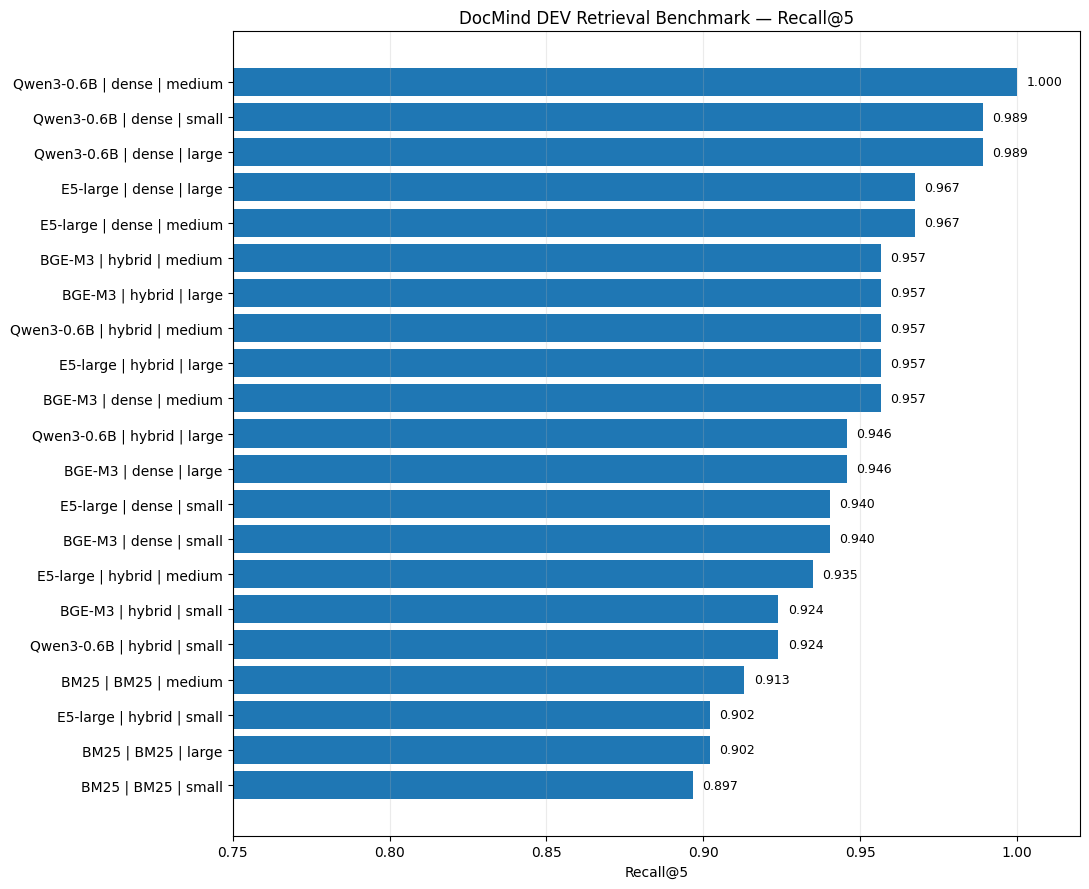

Saved: /kaggle/working/docmind_research/benchmark_plots/01_recall5_leaderboard.png


In [98]:
# ============================================================
# CELL 34 — RECALL@5 LEADERBOARD
# ============================================================

top = (
    plot_df
    .sort_values("Recall@5", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    top["label"],
    top["Recall@5"]
)

ax.set_xlabel("Recall@5")
ax.set_ylabel("")
ax.set_title(
    "DocMind DEV Retrieval Benchmark — Recall@5"
)

ax.set_xlim(0.75, 1.02)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    top["Recall@5"]
):
    ax.text(
        value + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

path = PLOT_DIR / "01_recall5_leaderboard.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

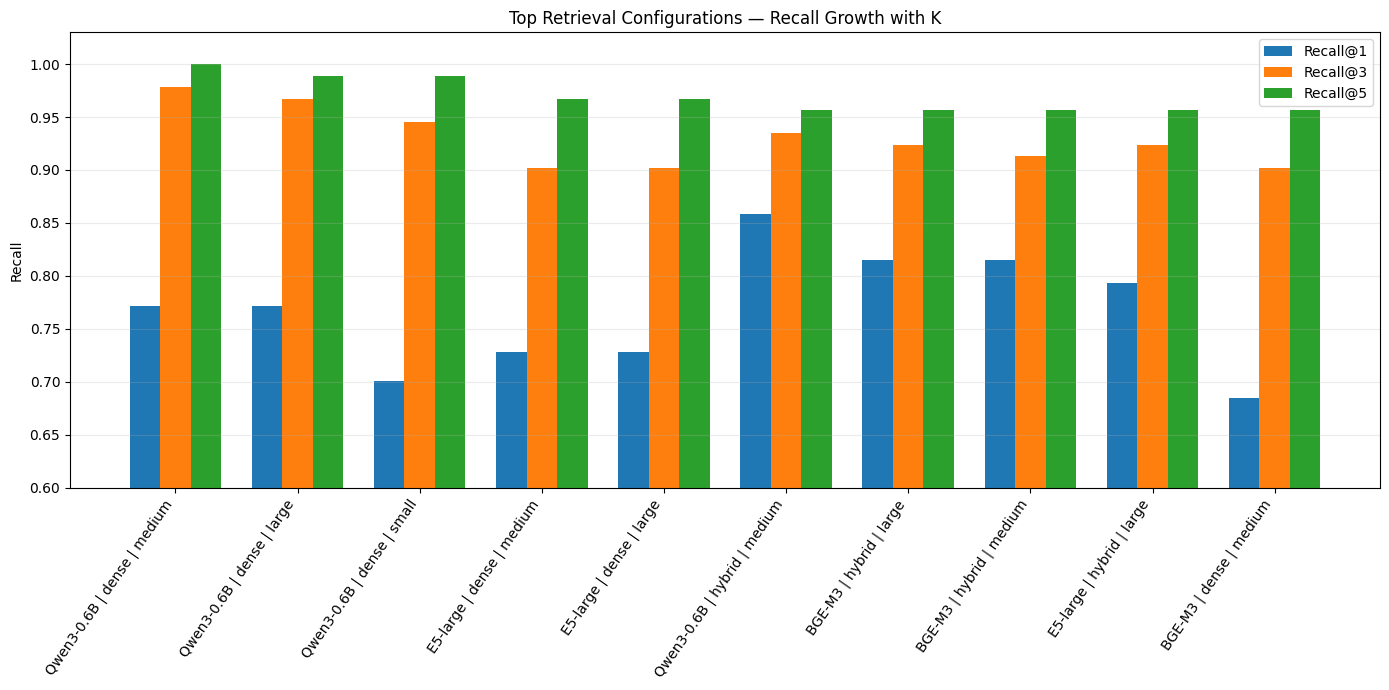

Saved: /kaggle/working/docmind_research/benchmark_plots/02_recall_at_k.png


In [99]:
# ============================================================
# CELL 35 — TOP-K RETRIEVAL CURVES
# ============================================================

top_n = 10

best = (
    plot_df
    .sort_values(
        ["Recall@5", "MRR@10"],
        ascending=False
    )
    .head(top_n)
    .copy()
)

metrics = [
    "Recall@1",
    "Recall@3",
    "Recall@5"
]

x = np.arange(len(best))
width = 0.25

fig, ax = plt.subplots(
    figsize=(14, 7)
)

for i, metric in enumerate(metrics):

    ax.bar(
        x + (i - 1) * width,
        best[metric],
        width,
        label=metric
    )

ax.set_xticks(x)

ax.set_xticklabels(
    best["label"],
    rotation=55,
    ha="right"
)

ax.set_ylim(0.6, 1.03)

ax.set_ylabel("Recall")
ax.set_title(
    "Top Retrieval Configurations — Recall Growth with K"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

path = PLOT_DIR / "02_recall_at_k.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

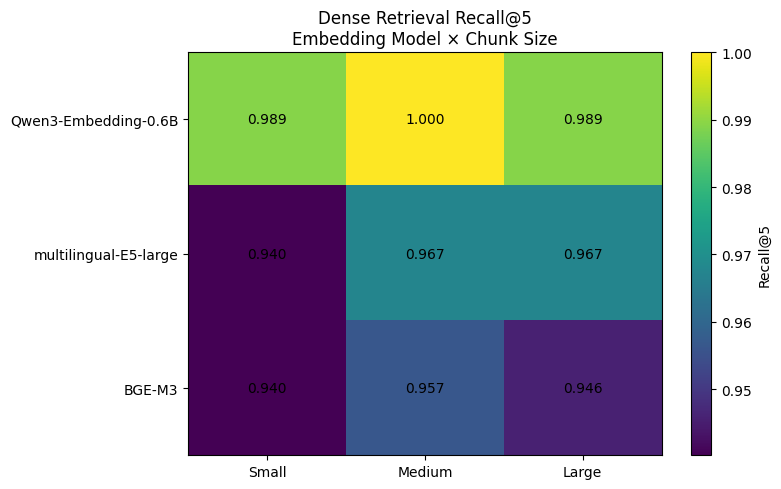

Saved: /kaggle/working/docmind_research/benchmark_plots/03_dense_heatmap.png


In [100]:
# ============================================================
# CELL 36 — DENSE RETRIEVAL HEATMAP
# ============================================================

dense = plot_df[
    plot_df["retriever"] == "dense"
].copy()

model_order = [
    "qwen3_06b",
    "e5_large",
    "bge_m3"
]

chunk_order = [
    "small",
    "medium",
    "large"
]

matrix = (
    dense
    .pivot(
        index="embedding_model",
        columns="chunk_config",
        values="Recall@5"
    )
    .reindex(
        index=model_order,
        columns=chunk_order
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

im = ax.imshow(
    matrix.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(chunk_order))
)

ax.set_xticklabels(
    ["Small", "Medium", "Large"]
)

ax.set_yticks(
    np.arange(len(model_order))
)

ax.set_yticklabels(
    [
        "Qwen3-Embedding-0.6B",
        "multilingual-E5-large",
        "BGE-M3"
    ]
)

ax.set_title(
    "Dense Retrieval Recall@5\nEmbedding Model × Chunk Size"
)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):

        value = matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Recall@5"
)

plt.tight_layout()

path = PLOT_DIR / "03_dense_heatmap.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

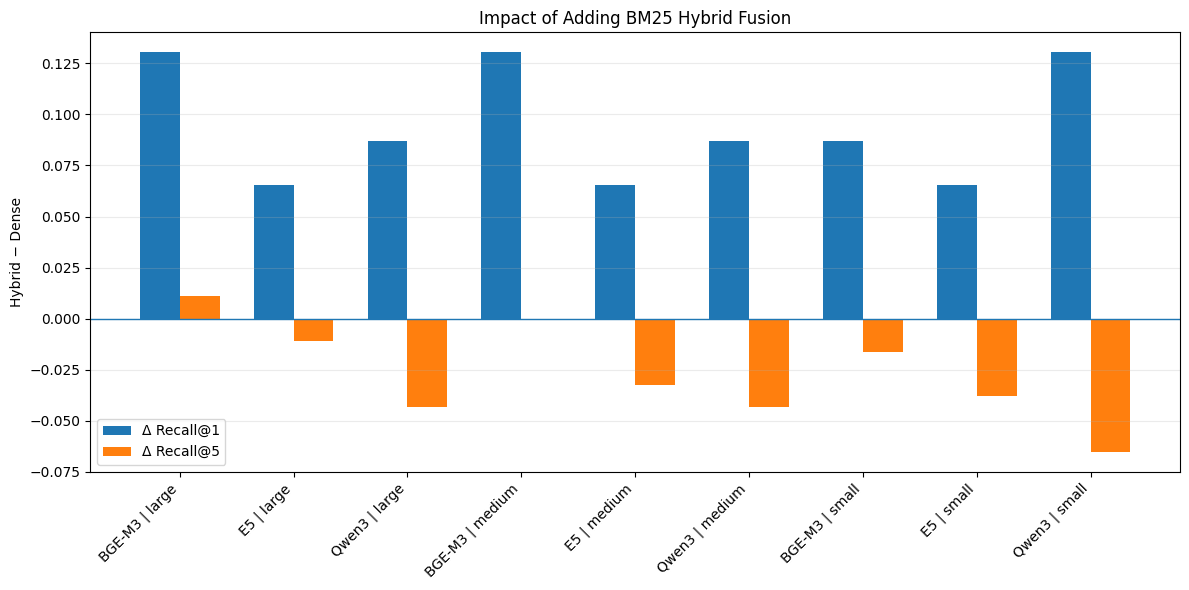

Saved: /kaggle/working/docmind_research/benchmark_plots/04_hybrid_delta.png


In [101]:
# ============================================================
# CELL 37 — DOES HYBRID ACTUALLY HELP?
# ============================================================

models_only = plot_df[
    plot_df["embedding_model"] != "none"
].copy()

comparison = (
    models_only
    .pivot_table(
        index=[
            "chunk_config",
            "embedding_model"
        ],
        columns="retriever",
        values=[
            "Recall@1",
            "Recall@5"
        ]
    )
)

comparison[
    ("delta", "Recall@1")
] = (
    comparison[
        ("Recall@1", "hybrid")
    ]
    -
    comparison[
        ("Recall@1", "dense")
    ]
)

comparison[
    ("delta", "Recall@5")
] = (
    comparison[
        ("Recall@5", "hybrid")
    ]
    -
    comparison[
        ("Recall@5", "dense")
    ]
)

delta = comparison["delta"].reset_index()

delta["label"] = (
    delta["embedding_model"].replace({
        "qwen3_06b": "Qwen3",
        "e5_large": "E5",
        "bge_m3": "BGE-M3"
    })
    + " | "
    + delta["chunk_config"]
)

x = np.arange(len(delta))
width = 0.35

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width/2,
    delta["Recall@1"],
    width,
    label="Δ Recall@1"
)

ax.bar(
    x + width/2,
    delta["Recall@5"],
    width,
    label="Δ Recall@5"
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xticks(x)

ax.set_xticklabels(
    delta["label"],
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Hybrid − Dense"
)

ax.set_title(
    "Impact of Adding BM25 Hybrid Fusion"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

path = PLOT_DIR / "04_hybrid_delta.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

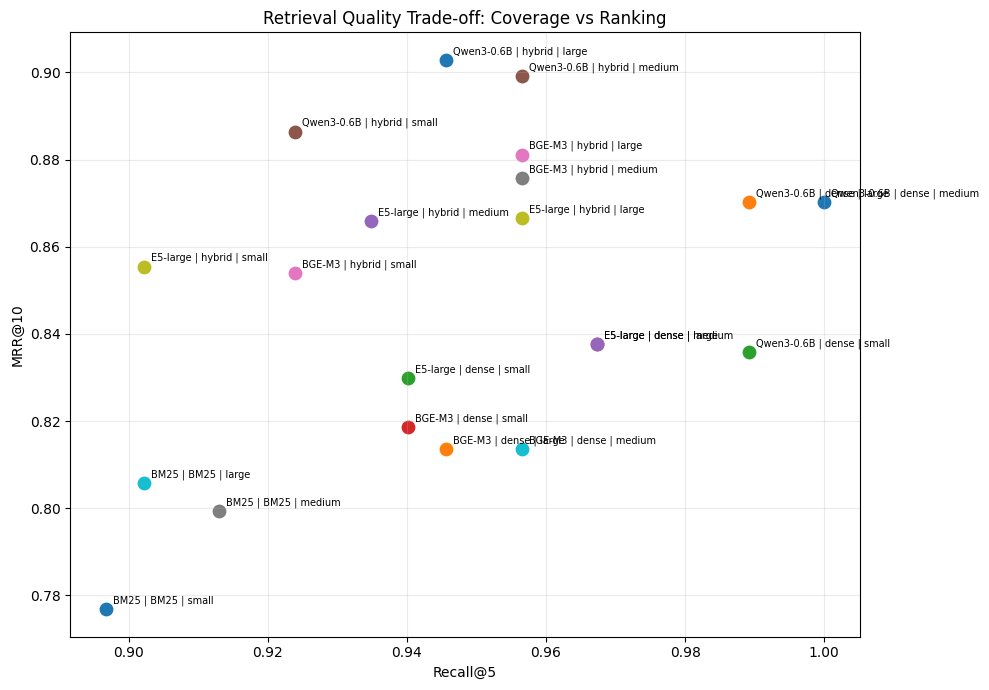

Saved: /kaggle/working/docmind_research/benchmark_plots/05_recall5_vs_mrr.png


In [102]:
# ============================================================
# CELL 38 — QUALITY TRADE-OFF
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for _, row in plot_df.iterrows():

    ax.scatter(
        row["Recall@5"],
        row["MRR@10"],
        s=80
    )

    ax.annotate(
        row["label"],
        (
            row["Recall@5"],
            row["MRR@10"]
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("Recall@5")
ax.set_ylabel("MRR@10")

ax.set_title(
    "Retrieval Quality Trade-off: Coverage vs Ranking"
)

ax.grid(alpha=0.25)

plt.tight_layout()

path = PLOT_DIR / "05_recall5_vs_mrr.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

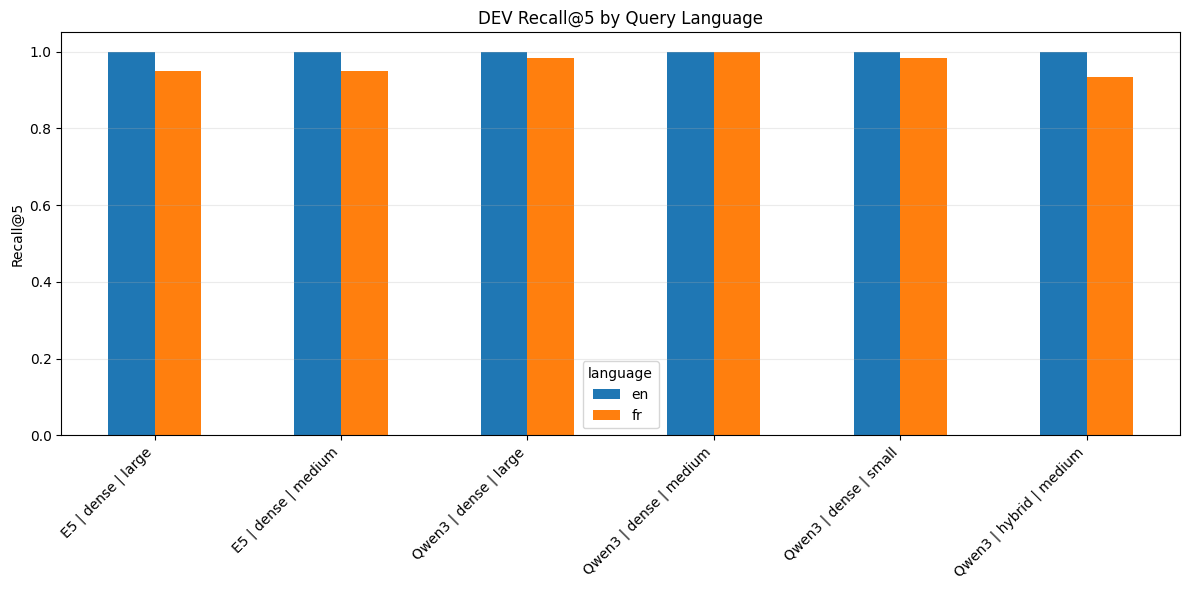

Saved: /kaggle/working/docmind_research/benchmark_plots/07_language_breakdown.png


language,en,fr
label,,
E5 | dense | large,1.0,0.950000
E5 | dense | medium,1.0,0.950000
Qwen3 | dense | large,1.0,0.983333
Qwen3 | dense | medium,1.0,1.000000
Qwen3 | dense | small,1.0,0.983333
Qwen3 | hybrid | medium,1.0,0.933333


In [103]:
# ============================================================
# CELL 40 — PERFORMANCE BY LANGUAGE
# ============================================================

language_rows = []

for key, detail_df in DEV_DETAILS.items():

    chunk_config, model, retriever = key

    grouped = (
        detail_df
        .groupby("language")[
            [
                "Recall@1",
                "Recall@3",
                "Recall@5",
                "MRR@10",
                "nDCG@10"
            ]
        ]
        .mean()
        .reset_index()
    )

    for _, row in grouped.iterrows():

        language_rows.append({
            "chunk_config": chunk_config,
            "embedding_model": model,
            "retriever": retriever,
            "language": row["language"],
            "Recall@5": row["Recall@5"],
            "MRR@10": row["MRR@10"]
        })


LANGUAGE_RESULTS = pd.DataFrame(
    language_rows
)

best_configs = (
    DEV_SUMMARY
    .head(6)[
        [
            "chunk_config",
            "embedding_model",
            "retriever"
        ]
    ]
)

selected = LANGUAGE_RESULTS.merge(
    best_configs,
    on=[
        "chunk_config",
        "embedding_model",
        "retriever"
    ]
)

selected["label"] = (
    selected["embedding_model"]
    .replace({
        "qwen3_06b": "Qwen3",
        "e5_large": "E5",
        "bge_m3": "BGE-M3",
        "none": "BM25"
    })
    + " | "
    + selected["retriever"]
    + " | "
    + selected["chunk_config"]
)


pivot = selected.pivot(
    index="label",
    columns="language",
    values="Recall@5"
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Recall@5")
plt.xlabel("")

plt.title(
    "DEV Recall@5 by Query Language"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

path = PLOT_DIR / "07_language_breakdown.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

display(pivot)

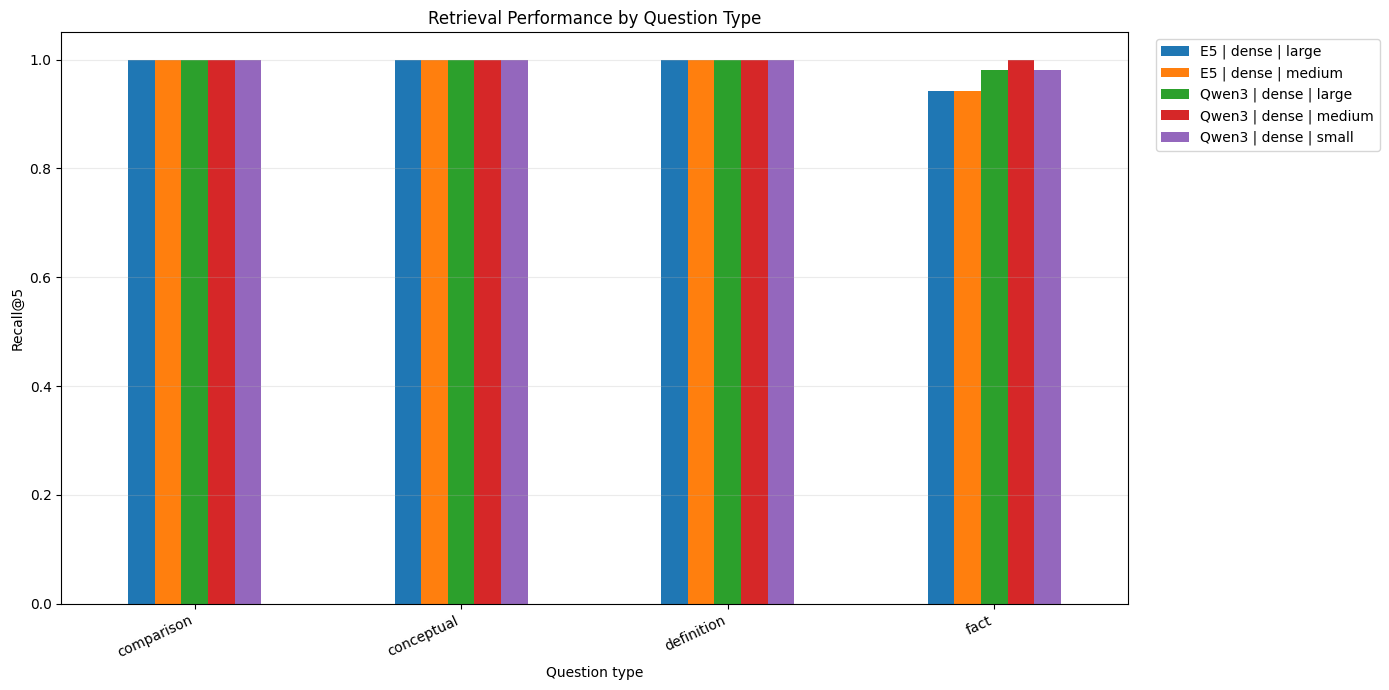

Saved: /kaggle/working/docmind_research/benchmark_plots/08_question_type_breakdown.png


label,E5 | dense | large,E5 | dense | medium,Qwen3 | dense | large,Qwen3 | dense | medium,Qwen3 | dense | small
question_type,,,,,
comparison,1.000000,1.000000,1.000000,1.0,1.000000
conceptual,1.000000,1.000000,1.000000,1.0,1.000000
definition,1.000000,1.000000,1.000000,1.0,1.000000
fact,0.942308,0.942308,0.980769,1.0,0.980769


In [104]:
# ============================================================
# CELL 41 — PERFORMANCE BY QUESTION TYPE
# ============================================================

type_rows = []

for key, detail_df in DEV_DETAILS.items():

    chunk_config, model, retriever = key

    grouped = (
        detail_df
        .groupby("question_type")[
            [
                "Recall@1",
                "Recall@5",
                "MRR@10"
            ]
        ]
        .mean()
        .reset_index()
    )

    for _, row in grouped.iterrows():

        type_rows.append({
            "chunk_config": chunk_config,
            "embedding_model": model,
            "retriever": retriever,
            "question_type": row["question_type"],
            "Recall@5": row["Recall@5"],
            "MRR@10": row["MRR@10"]
        })


TYPE_RESULTS = pd.DataFrame(type_rows)


# Compare top 5 configurations only
top5 = DEV_SUMMARY.head(5)[
    [
        "chunk_config",
        "embedding_model",
        "retriever"
    ]
]

selected = TYPE_RESULTS.merge(
    top5,
    on=[
        "chunk_config",
        "embedding_model",
        "retriever"
    ]
)

selected["label"] = (
    selected["embedding_model"]
    .replace({
        "qwen3_06b": "Qwen3",
        "e5_large": "E5",
        "bge_m3": "BGE-M3",
        "none": "BM25"
    })
    + " | "
    + selected["retriever"]
    + " | "
    + selected["chunk_config"]
)


pivot = selected.pivot(
    index="question_type",
    columns="label",
    values="Recall@5"
)

ax = pivot.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_ylabel("Recall@5")
ax.set_xlabel("Question type")

ax.set_title(
    "Retrieval Performance by Question Type"
)

ax.set_ylim(0, 1.05)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

path = PLOT_DIR / "08_question_type_breakdown.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", path)

display(pivot)

In [105]:
# ============================================================
# CELL 42 — REPORT TABLE
# ============================================================

REPORT_TABLE = (
    DEV_SUMMARY[
        [
            "chunk_config",
            "embedding_model",
            "retriever",
            "Recall@1",
            "Recall@3",
            "Recall@5",
            "MRR@10",
            "nDCG@10",
            "latency_ms"
        ]
    ]
    .copy()
)

REPORT_TABLE["embedding_model"] = (
    REPORT_TABLE["embedding_model"]
    .replace({
        "qwen3_06b":
            "Qwen3-Embedding-0.6B",

        "e5_large":
            "multilingual-E5-large",

        "bge_m3":
            "BGE-M3",

        "none":
            "-"
    })
)

display(
    REPORT_TABLE.style
    .format({
        "Recall@1": "{:.3f}",
        "Recall@3": "{:.3f}",
        "Recall@5": "{:.3f}",
        "MRR@10": "{:.3f}",
        "nDCG@10": "{:.3f}",
        "latency_ms": "{:.3f}",
    })
    .background_gradient(
        subset=[
            "Recall@1",
            "Recall@3",
            "Recall@5",
            "MRR@10",
            "nDCG@10"
        ]
    )
)

,chunk_config,embedding_model,retriever,Recall@1,Recall@3,Recall@5,MRR@10,nDCG@10,latency_ms
0,medium,Qwen3-Embedding-0.6B,dense,0.772,0.978,1.000,0.870,0.903,0.119
1,large,Qwen3-Embedding-0.6B,dense,0.772,0.967,0.989,0.870,0.899,0.114
2,small,Qwen3-Embedding-0.6B,dense,0.701,0.946,0.989,0.836,0.868,0.163
3,medium,multilingual-E5-large,dense,0.728,0.902,0.967,0.838,0.869,0.120
4,large,multilingual-E5-large,dense,0.728,0.902,0.967,0.838,0.869,0.107
5,medium,Qwen3-Embedding-0.6B,hybrid,0.859,0.935,0.957,0.899,0.912,4.255
6,large,BGE-M3,hybrid,0.815,0.924,0.957,0.881,0.898,3.740
7,medium,BGE-M3,hybrid,0.815,0.913,0.957,0.876,0.894,4.256
8,large,multilingual-E5-large,hybrid,0.793,0.924,0.957,0.867,0.886,3.730
9,medium,BGE-M3,dense,0.685,0.902,0.957,0.814,0.857,0.119


In [106]:
# ============================================================
# CELL 43 — EVIDENCE-GROUP GOLD LABELS
# ============================================================

def build_gold_evidence_groups(
    questions,
    chunks
):

    result = {}

    for q in questions:

        groups = []

        for evidence in q.get(
            "gold_evidence",
            []
        ):

            matching_chunks = {
                chunk["chunk_id"]
                for chunk in chunks
                if evidence_matches_chunk(
                    evidence,
                    chunk
                )
            }

            groups.append(
                matching_chunks
            )

        result[
            q["question_id"]
        ] = groups

    return result

In [107]:
def evidence_recall_at_k(
    ranking,
    evidence_groups,
    k
):

    if not evidence_groups:
        return 0.0

    retrieved = set(
        ranking[:k]
    )

    covered = sum(
        bool(
            retrieved & group
        )
        for group in evidence_groups
    )

    return covered / len(
        evidence_groups
    )

In [108]:
def complete_evidence_at_k(
    ranking,
    evidence_groups,
    k
):

    if not evidence_groups:
        return 0.0

    retrieved = set(
        ranking[:k]
    )

    return float(
        all(
            bool(retrieved & group)
            for group in evidence_groups
        )
    )

In [109]:
# ============================================================
# CHECK CompleteEvidence@5 ON ALL DEV CONFIGURATIONS
# ============================================================

COMPLETE_RESULTS = []

for key, rankings in DEV_RANKINGS.items():

    chunk_config, model, retriever = key

    chunks = chunks_by_config[chunk_config]

    evidence_groups = build_gold_evidence_groups(
        dev_questions,
        chunks
    )

    per_question = []

    for q in dev_questions:

        qid = q["question_id"]

        score = complete_evidence_at_k(
            rankings[qid],
            evidence_groups[qid],
            k=5
        )

        per_question.append(score)

    COMPLETE_RESULTS.append({
        "chunk_config": chunk_config,
        "embedding_model": model,
        "retriever": retriever,
        "CompleteEvidence@5": np.mean(per_question),
        "complete_questions": int(np.sum(per_question)),
        "total_questions": len(per_question),
    })


COMPLETE_DF = (
    pd.DataFrame(COMPLETE_RESULTS)
    .sort_values(
        "CompleteEvidence@5",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    COMPLETE_DF.style.format({
        "CompleteEvidence@5": "{:.4f}"
    })
)

,chunk_config,embedding_model,retriever,CompleteEvidence@5,complete_questions,total_questions
0,small,qwen3_06b,dense,1.0000,46,46
1,medium,qwen3_06b,dense,1.0000,46,46
2,large,qwen3_06b,dense,1.0000,46,46
3,large,e5_large,dense,0.9783,45,46
4,medium,e5_large,dense,0.9565,44,46
5,large,e5_large,hybrid,0.9565,44,46
6,large,bge_m3,hybrid,0.9565,44,46
7,large,qwen3_06b,hybrid,0.9565,44,46
8,large,bge_m3,dense,0.9565,44,46
9,medium,bge_m3,hybrid,0.9565,44,46


In [110]:
DEV_SUMMARY_V2 = DEV_SUMMARY.merge(
    COMPLETE_DF[
        [
            "chunk_config",
            "embedding_model",
            "retriever",
            "CompleteEvidence@5"
        ]
    ],
    on=[
        "chunk_config",
        "embedding_model",
        "retriever"
    ],
    how="left"
)

DEV_SUMMARY_V2 = (
    DEV_SUMMARY_V2
    .sort_values(
        [
            "CompleteEvidence@5",
            "Recall@5",
            "MRR@10"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    DEV_SUMMARY_V2.style.format({
        "Recall@1": "{:.4f}",
        "Recall@3": "{:.4f}",
        "Recall@5": "{:.4f}",
        "CompleteEvidence@5": "{:.4f}",
        "MRR@10": "{:.4f}",
        "nDCG@10": "{:.4f}",
    })
)

,chunk_config,embedding_model,retriever,latency_ms,Recall@1,Recall@3,Recall@5,MRR@10,nDCG@10,CompleteEvidence@5
0,medium,qwen3_06b,dense,0.118571,0.7717,0.9783,1.0000,0.8703,0.9031,1.0000
1,large,qwen3_06b,dense,0.114191,0.7717,0.9674,0.9891,0.8703,0.8991,1.0000
2,small,qwen3_06b,dense,0.163328,0.7011,0.9457,0.9891,0.8359,0.8685,1.0000
3,large,e5_large,dense,0.107462,0.7283,0.9022,0.9674,0.8377,0.8687,0.9783
4,medium,e5_large,dense,0.119784,0.7283,0.9022,0.9674,0.8377,0.8687,0.9565
5,medium,qwen3_06b,hybrid,4.255245,0.8587,0.9348,0.9565,0.8993,0.9117,0.9565
6,large,bge_m3,hybrid,3.739512,0.8152,0.9239,0.9565,0.8812,0.8976,0.9565
7,medium,bge_m3,hybrid,4.255881,0.8152,0.9130,0.9565,0.8757,0.8941,0.9565
8,large,e5_large,hybrid,3.730334,0.7935,0.9239,0.9565,0.8667,0.8861,0.9565
9,medium,bge_m3,dense,0.118959,0.6848,0.9022,0.9565,0.8136,0.8566,0.9565


In [111]:
# ============================================================
# CORRECT EVIDENCE-LEVEL RETRIEVAL METRICS
# ============================================================

def evidence_recall_at_k(
    ranking,
    evidence_groups,
    k
):
    if not evidence_groups:
        return 0.0

    retrieved = set(ranking[:k])

    covered = sum(
        bool(retrieved & group)
        for group in evidence_groups
    )

    return covered / len(evidence_groups)


EVIDENCE_RESULTS = []

for key, rankings in DEV_RANKINGS.items():

    chunk_config, model, retriever = key

    groups_map = build_gold_evidence_groups(
        dev_questions,
        chunks_by_config[chunk_config]
    )

    rows = []

    for q in dev_questions:

        qid = q["question_id"]
        ranking = rankings[qid]
        groups = groups_map[qid]

        rows.append({
            "EvidenceRecall@1":
                evidence_recall_at_k(
                    ranking, groups, 1
                ),

            "EvidenceRecall@3":
                evidence_recall_at_k(
                    ranking, groups, 3
                ),

            "EvidenceRecall@5":
                evidence_recall_at_k(
                    ranking, groups, 5
                ),

            "CompleteEvidence@5":
                complete_evidence_at_k(
                    ranking, groups, 5
                )
        })

    df = pd.DataFrame(rows)

    EVIDENCE_RESULTS.append({
        "chunk_config": chunk_config,
        "embedding_model": model,
        "retriever": retriever,

        "EvidenceRecall@1":
            df["EvidenceRecall@1"].mean(),

        "EvidenceRecall@3":
            df["EvidenceRecall@3"].mean(),

        "EvidenceRecall@5":
            df["EvidenceRecall@5"].mean(),

        "CompleteEvidence@5":
            df["CompleteEvidence@5"].mean(),
    })


EVIDENCE_SUMMARY = (
    pd.DataFrame(EVIDENCE_RESULTS)
    .sort_values(
        [
            "CompleteEvidence@5",
            "EvidenceRecall@5",
            "EvidenceRecall@3"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    EVIDENCE_SUMMARY.style.format({
        "EvidenceRecall@1": "{:.4f}",
        "EvidenceRecall@3": "{:.4f}",
        "EvidenceRecall@5": "{:.4f}",
        "CompleteEvidence@5": "{:.4f}",
    })
)

,chunk_config,embedding_model,retriever,EvidenceRecall@1,EvidenceRecall@3,EvidenceRecall@5,CompleteEvidence@5
0,medium,qwen3_06b,dense,0.7754,0.9783,1.0000,1.0000
1,large,qwen3_06b,dense,0.7826,0.9783,1.0000,1.0000
2,small,qwen3_06b,dense,0.7101,0.9565,1.0000,1.0000
3,large,e5_large,dense,0.7391,0.9130,0.9783,0.9783
4,medium,e5_large,dense,0.7319,0.9058,0.9710,0.9565
5,medium,qwen3_06b,hybrid,0.8623,0.9348,0.9565,0.9565
6,large,bge_m3,hybrid,0.8261,0.9348,0.9565,0.9565
7,large,e5_large,hybrid,0.8043,0.9348,0.9565,0.9565
8,large,qwen3_06b,hybrid,0.8696,0.9348,0.9565,0.9565
9,medium,bge_m3,hybrid,0.8188,0.9130,0.9565,0.9565


In [112]:
!pip install -q FlagEmbedding

In [113]:
from FlagEmbedding import FlagReranker
import torch
import gc

reranker = FlagReranker(
    "BAAI/bge-reranker-v2-m3",
    use_fp16=True
)

print("✅ Reranker loaded")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

✅ Reranker loaded


In [114]:
# ============================================================
# RERANK TOP-N RETRIEVAL RESULTS
# ============================================================

def rerank_results(
    questions,
    rankings,
    chunks,
    top_n=30,
    final_k=50
):

    chunk_lookup = {
        c["chunk_id"]: c
        for c in chunks
    }

    reranked = {}

    for q in tqdm(
        questions,
        desc="Reranking"
    ):

        qid = q["question_id"]

        candidate_ids = rankings[qid][:top_n]

        pairs = [
            [
                q["question"],
                chunk_lookup[cid]["text"]
            ]
            for cid in candidate_ids
        ]

        scores = reranker.compute_score(
            pairs,
            normalize=True
        )

        ranked_pairs = sorted(
            zip(candidate_ids, scores),
            key=lambda x: x[1],
            reverse=True
        )

        reranked_ids = [
            cid
            for cid, score in ranked_pairs
        ]

        # Keep untouched results after reranked candidates
        remainder = [
            cid
            for cid in rankings[qid]
            if cid not in set(reranked_ids)
        ]

        reranked[qid] = (
            reranked_ids + remainder
        )[:final_k]

    return reranked

In [116]:
# ============================================================
# RERANKER — DIRECT TRANSFORMERS VERSION
# ============================================================

import gc
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

RERANKER_NAME = "BAAI/bge-reranker-v2-m3"
RERANK_DEVICE = torch.device("cuda:0")

# Clean up previous models
gc.collect()
torch.cuda.empty_cache()

print("GPU:", torch.cuda.get_device_name(0))
print("Loading:", RERANKER_NAME)

rerank_tokenizer = AutoTokenizer.from_pretrained(
    RERANKER_NAME
)

rerank_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        RERANKER_NAME,
        torch_dtype=torch.float16
    )
    .to(RERANK_DEVICE)
)

rerank_model.eval()

print("✅ Reranker loaded on cuda:0")

GPU: Tesla T4
Loading: BAAI/bge-reranker-v2-m3


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

✅ Reranker loaded on cuda:0


In [117]:
# ============================================================
# RERANKER SMOKE TEST
# ============================================================

test_pairs = [
    (
        "What is machine learning?",
        "Machine learning allows computers to learn from data."
    ),
    (
        "What is machine learning?",
        "Paris is the capital of France."
    ),
]

with torch.inference_mode():

    inputs = rerank_tokenizer(
        [x[0] for x in test_pairs],
        [x[1] for x in test_pairs],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(RERANK_DEVICE)
        for k, v in inputs.items()
    }

    scores = (
        rerank_model(**inputs)
        .logits
        .view(-1)
        .float()
        .cpu()
        .numpy()
    )

print(scores)

[  4.2421875 -11.0234375]


In [118]:
# ============================================================
# FAST BATCHED RERANKING
# ============================================================

from tqdm.auto import tqdm
import numpy as np


def score_reranker_pairs(
    queries,
    passages,
    batch_size=16,
    max_length=1024
):

    assert len(queries) == len(passages)

    all_scores = []

    for start in tqdm(
        range(0, len(queries), batch_size),
        desc="Reranker batches"
    ):

        end = min(
            start + batch_size,
            len(queries)
        )

        batch_queries = queries[start:end]
        batch_passages = passages[start:end]

        encoded = rerank_tokenizer(
            batch_queries,
            batch_passages,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(
                RERANK_DEVICE,
                non_blocking=True
            )
            for key, value in encoded.items()
        }

        with torch.inference_mode():

            logits = (
                rerank_model(**encoded)
                .logits
                .view(-1)
            )

        all_scores.extend(
            logits
            .float()
            .cpu()
            .numpy()
            .tolist()
        )

    return np.asarray(
        all_scores,
        dtype=np.float32
    )


def rerank_results_batched(
    questions,
    rankings,
    chunks,
    top_n=30,
    final_k=50,
    batch_size=16
):

    chunk_lookup = {
        c["chunk_id"]: c
        for c in chunks
    }

    # --------------------------------------------------------
    # Flatten every query/candidate pair
    # --------------------------------------------------------

    records = []

    for q in questions:

        qid = q["question_id"]

        candidate_ids = rankings[qid][:top_n]

        for cid in candidate_ids:

            records.append({
                "question_id": qid,
                "chunk_id": cid,
                "query": q["question"],
                "passage": chunk_lookup[cid]["text"]
            })

    print(
        "Pairs to rerank:",
        len(records)
    )

    queries = [
        r["query"]
        for r in records
    ]

    passages = [
        r["passage"]
        for r in records
    ]

    # --------------------------------------------------------
    # GPU scoring
    # --------------------------------------------------------

    scores = score_reranker_pairs(
        queries,
        passages,
        batch_size=batch_size,
        max_length=1024
    )

    for record, score in zip(
        records,
        scores
    ):
        record["score"] = float(score)

    # --------------------------------------------------------
    # Reconstruct rankings
    # --------------------------------------------------------

    reranked = {}

    for q in questions:

        qid = q["question_id"]

        candidate_records = [
            r
            for r in records
            if r["question_id"] == qid
        ]

        candidate_records.sort(
            key=lambda x: x["score"],
            reverse=True
        )

        reranked_ids = [
            r["chunk_id"]
            for r in candidate_records
        ]

        candidate_set = set(
            reranked_ids
        )

        remainder = [
            cid
            for cid in rankings[qid]
            if cid not in candidate_set
        ]

        reranked[qid] = (
            reranked_ids
            +
            remainder
        )[:final_k]

    return reranked

In [119]:
# ============================================================
# TEST RERANKING ON CURRENT DEV WINNER
# ============================================================

key = (
    "medium",
    "qwen3_06b",
    "dense"
)

print("Reranking:", key)

MEDIUM_QWEN_RERANKED = rerank_results_batched(
    questions=dev_questions,

    rankings=DEV_RANKINGS[key],

    chunks=chunks_by_config[
        "medium"
    ],

    top_n=30,

    batch_size=16
)

print("✅ Finished")

Reranking: ('medium', 'qwen3_06b', 'dense')
Pairs to rerank: 1380


Reranker batches:   0%|          | 0/87 [00:00<?, ?it/s]

✅ Finished


In [120]:
# ============================================================
# BEFORE vs AFTER — CURRENT WINNER
# ============================================================

key = (
    "medium",
    "qwen3_06b",
    "dense"
)

groups_map = build_gold_evidence_groups(
    dev_questions,
    chunks_by_config["medium"]
)


def summarize_evidence_metrics(
    rankings,
    groups_map
):

    rows = []

    for q in dev_questions:

        qid = q["question_id"]
        groups = groups_map[qid]

        rows.append({

            "EvidenceRecall@1":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    1
                ),

            "EvidenceRecall@3":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    3
                ),

            "EvidenceRecall@5":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    5
                ),

            "CompleteEvidence@5":
                complete_evidence_at_k(
                    rankings[qid],
                    groups,
                    5
                ),
        })

    df = pd.DataFrame(rows)

    return df.mean()


before = summarize_evidence_metrics(
    DEV_RANKINGS[key],
    groups_map
)

after = summarize_evidence_metrics(
    MEDIUM_QWEN_RERANKED,
    groups_map
)


comparison = pd.DataFrame({
    "Before reranker": before,
    "After reranker": after
})

display(
    comparison.style.format(
        "{:.4f}"
    )
)

,Before reranker,After reranker
EvidenceRecall@1,0.7754,0.9058
EvidenceRecall@3,0.9783,0.9348
EvidenceRecall@5,1.0000,0.9783
CompleteEvidence@5,1.0000,0.9783


In [121]:
FINALISTS = [
    ("medium", "qwen3_06b", "dense"),
    ("large",  "qwen3_06b", "dense"),
    ("small",  "qwen3_06b", "dense"),
    ("medium", "qwen3_06b", "hybrid"),
]


RERANKED_DEV = {}


for key in FINALISTS:

    chunk_config, model, retriever = key

    print("\n" + "=" * 80)
    print("RERANK:", key)
    print("=" * 80)

    RERANKED_DEV[key] = (
        rerank_results_batched(

            questions=dev_questions,

            rankings=DEV_RANKINGS[key],

            chunks=chunks_by_config[
                chunk_config
            ],

            top_n=30,

            batch_size=16
        )
    )


print("\n✅ All finalists reranked")


RERANK: ('medium', 'qwen3_06b', 'dense')
Pairs to rerank: 1380


Reranker batches:   0%|          | 0/87 [00:00<?, ?it/s]


RERANK: ('large', 'qwen3_06b', 'dense')
Pairs to rerank: 1380


Reranker batches:   0%|          | 0/87 [00:00<?, ?it/s]


RERANK: ('small', 'qwen3_06b', 'dense')
Pairs to rerank: 1380


Reranker batches:   0%|          | 0/87 [00:00<?, ?it/s]


RERANK: ('medium', 'qwen3_06b', 'hybrid')
Pairs to rerank: 1380


Reranker batches:   0%|          | 0/87 [00:00<?, ?it/s]


✅ All finalists reranked


In [122]:
# ============================================================
# EVALUATE ALL RERANKED FINALISTS
# ============================================================

RERANK_RESULTS = []

for key, rankings in RERANKED_DEV.items():

    chunk_config, model, retriever = key

    groups_map = build_gold_evidence_groups(
        dev_questions,
        chunks_by_config[chunk_config]
    )

    rows = []

    for q in dev_questions:

        qid = q["question_id"]
        groups = groups_map[qid]

        rows.append({
            "EvidenceRecall@1":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    1
                ),

            "EvidenceRecall@3":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    3
                ),

            "EvidenceRecall@5":
                evidence_recall_at_k(
                    rankings[qid],
                    groups,
                    5
                ),

            "CompleteEvidence@5":
                complete_evidence_at_k(
                    rankings[qid],
                    groups,
                    5
                ),
        })

    df = pd.DataFrame(rows)

    RERANK_RESULTS.append({
        "chunk_config": chunk_config,
        "embedding_model": model,
        "base_retriever": retriever,

        "EvidenceRecall@1":
            df["EvidenceRecall@1"].mean(),

        "EvidenceRecall@3":
            df["EvidenceRecall@3"].mean(),

        "EvidenceRecall@5":
            df["EvidenceRecall@5"].mean(),

        "CompleteEvidence@5":
            df["CompleteEvidence@5"].mean(),
    })


RERANK_SUMMARY = (
    pd.DataFrame(RERANK_RESULTS)
    .sort_values(
        [
            "CompleteEvidence@5",
            "EvidenceRecall@5",
            "EvidenceRecall@1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    RERANK_SUMMARY.style.format({
        "EvidenceRecall@1": "{:.4f}",
        "EvidenceRecall@3": "{:.4f}",
        "EvidenceRecall@5": "{:.4f}",
        "CompleteEvidence@5": "{:.4f}",
    })
)

,chunk_config,embedding_model,base_retriever,EvidenceRecall@1,EvidenceRecall@3,EvidenceRecall@5,CompleteEvidence@5
0,medium,qwen3_06b,hybrid,0.8841,0.9348,1.0000,1.0000
1,medium,qwen3_06b,dense,0.9058,0.9348,0.9783,0.9783
2,large,qwen3_06b,dense,0.8913,0.9348,0.9783,0.9783
3,small,qwen3_06b,dense,0.8841,0.9348,0.9783,0.9783


In [123]:
# ============================================================
# BASE vs RERANKED
# ============================================================

comparison_rows = []

for key in FINALISTS:

    chunk_config, model, retriever = key

    groups_map = build_gold_evidence_groups(
        dev_questions,
        chunks_by_config[chunk_config]
    )

    for version, rankings in [
        ("Base", DEV_RANKINGS[key]),
        ("Reranked", RERANKED_DEV[key]),
    ]:

        values = []

        for q in dev_questions:

            qid = q["question_id"]
            groups = groups_map[qid]

            values.append({
                "ER1": evidence_recall_at_k(
                    rankings[qid], groups, 1
                ),

                "ER3": evidence_recall_at_k(
                    rankings[qid], groups, 3
                ),

                "ER5": evidence_recall_at_k(
                    rankings[qid], groups, 5
                ),

                "Complete5": complete_evidence_at_k(
                    rankings[qid], groups, 5
                )
            })

        tmp = pd.DataFrame(values)

        comparison_rows.append({
            "chunk": chunk_config,
            "model": model,
            "retriever": retriever,
            "version": version,

            "EvidenceRecall@1":
                tmp["ER1"].mean(),

            "EvidenceRecall@3":
                tmp["ER3"].mean(),

            "EvidenceRecall@5":
                tmp["ER5"].mean(),

            "CompleteEvidence@5":
                tmp["Complete5"].mean(),
        })


BASE_VS_RERANK = pd.DataFrame(
    comparison_rows
)

display(
    BASE_VS_RERANK.style.format({
        "EvidenceRecall@1": "{:.4f}",
        "EvidenceRecall@3": "{:.4f}",
        "EvidenceRecall@5": "{:.4f}",
        "CompleteEvidence@5": "{:.4f}",
    })
)

,chunk,model,retriever,version,EvidenceRecall@1,EvidenceRecall@3,EvidenceRecall@5,CompleteEvidence@5
0,medium,qwen3_06b,dense,Base,0.7754,0.9783,1.0000,1.0000
1,medium,qwen3_06b,dense,Reranked,0.9058,0.9348,0.9783,0.9783
2,large,qwen3_06b,dense,Base,0.7826,0.9783,1.0000,1.0000
3,large,qwen3_06b,dense,Reranked,0.8913,0.9348,0.9783,0.9783
4,small,qwen3_06b,dense,Base,0.7101,0.9565,1.0000,1.0000
5,small,qwen3_06b,dense,Reranked,0.8841,0.9348,0.9783,0.9783
6,medium,qwen3_06b,hybrid,Base,0.8623,0.9348,0.9565,0.9565
7,medium,qwen3_06b,hybrid,Reranked,0.8841,0.9348,1.0000,1.0000


'/kaggle/working/docmind_research.zip'

In [125]:
# ============================================================
# EXPORT FROZEN DEV CONTEXTS FOR GENERATION BENCHMARK
# ============================================================

import json
from pathlib import Path

FROZEN_RETRIEVAL_KEY = (
    "medium",
    "qwen3_06b",
    "hybrid"
)

# Use the reranked version that achieved:
# EvidenceRecall@5 = 1.0
# CompleteEvidence@5 = 1.0
frozen_rankings = RERANKED_DEV[
    FROZEN_RETRIEVAL_KEY
]

frozen_chunks = chunks_by_config[
    "medium"
]

chunk_lookup = {
    c["chunk_id"]: c
    for c in frozen_chunks
}

generation_records = []

for q in dev_questions:

    qid = q["question_id"]

    top_ids = frozen_rankings[qid][:5]

    contexts = []

    for rank, cid in enumerate(
        top_ids,
        start=1
    ):

        chunk = chunk_lookup[cid]

        contexts.append({
            "source_id": f"S{rank}",
            "rank": rank,
            "chunk_id": cid,
            "document_id": chunk["doc_id"],
            "location_type": chunk["location_type"],
            "location_value": chunk["location_value"],
            "text": chunk["text"],
        })

    generation_records.append({
        "question_id": qid,
        "question": q["question"],
        "language": q["language"],
        "question_type": q["question_type"],
        "answerable": True,
        "expected_answer": q.get(
            "expected_answer"
        ),
        "contexts": contexts,
    })


generation_benchmark = {
    "schema_version": "1.0",

    "split": "DEV",

    "retrieval_frozen": True,

    "retrieval_config": {
        "chunk_config": "medium",
        "chunk_tokens": 320,
        "embedding_model":
            "Qwen/Qwen3-Embedding-0.6B",
        "retrieval":
            "Dense + BM25 RRF",
        "reranker":
            "BAAI/bge-reranker-v2-m3",
        "top_k": 5,
    },

    "records": generation_records,
}


GENERATION_DEV_PATH = (
    WORK_DIR /
    "docmind_generation_dev_frozen.json"
)

with open(
    GENERATION_DEV_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        generation_benchmark,
        f,
        ensure_ascii=False,
        indent=2
    )


print("✅ FROZEN GENERATION BENCHMARK")
print("Questions:", len(generation_records))
print("Contexts/question: 5")
print("Saved:", GENERATION_DEV_PATH)

assert len(generation_records) == 46


✅ FROZEN GENERATION BENCHMARK
Questions: 46
Contexts/question: 5
Saved: /kaggle/working/docmind_research/docmind_generation_dev_frozen.json


In [127]:
import shutil

# Compress /kaggle/working/docmind_research into docmind_research.zip
shutil.make_archive('docmind_research', 'zip', '/kaggle/working/docmind_research')

'/kaggle/working/docmind_research.zip'